# Immgen ATAC-Seq


In [648]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm.auto import tqdm
import re
import tempfile
import pyranges as pr
from pyranges import PyRanges
from statannotations.Annotator import Annotator

sns.set_context("paper", rc={"font.size": 8})

In [649]:
PATH = os.path.expanduser('~/data/2024_Immgen')
! mkdir -p {PATH}/pics

def file_to_name(file):
    return re.sub('(.*SRR[0-9]+_)|(_ATAC_seq.*)', '', os.path.basename(file))


def file_to_srr(file):
    return re.sub('_.*', '', os.path.basename(file))

In [650]:
def bedl(file):
    try:
        tf = pd.read_csv(file, sep='\t', header=None)
        return tf[2] - tf[1]
    except:
        return np.zeros(0)  # Empty file


def lines(file):
    try:
        tf = pd.read_csv(file, sep='\t', header=None)
        return len(tf)
    except:
        return 0  # Empty file


def d(a, b):
    return a / b if b != 0 else 0


def sorted_file(file):
    ts = tempfile.mktemp()
    !cat {file} | sort -k1,1 -k2,2n > {ts}
    # Fixes of problems with peakseq output
    ! sed -E -i 's/[[:space:]]+/\t/g' {ts}
    ! sed -E -i 's/\t$//g' {ts}
    return ts


def sorted_file10(file):
    ts = tempfile.mktemp()
    ! cat {file} | cut -f1-10 | sort -k1,1 -k2,2n -k3,3n > {ts}
    # Fixes problems with peakseq output
    ! sed -E -i 's/[[:space:]]+/\t/g' {ts}
    ! sed -E -i 's/\t$//g' {ts}
    return ts


def load_or_compute(path, compute):
    if os.path.exists(path):
        return pd.read_csv(path, sep='\t')
    else:
        df = compute()
        df.to_csv(path, sep='\t', index=False)
        return df

# Load peaks

In [651]:
# Keep the same coloring, even though some peak caller tools doesn't support no-control settings
import matplotlib.colors as mc
import colorsys


def adjust_lightness(c, amount=0.5):
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2])


TOOLS = ['MACS2', 'SICER', 'Omnipeak', 'HOMER', 'Hotspot', 'Peakseq', 'LanceOtron']
palette = plt.get_cmap('tab10')
TOOLS_PALETTE = {t: palette(i) for i, t in enumerate(TOOLS)}

TOOLS_PALETTE['MACS2 broad'] = adjust_lightness(TOOLS_PALETTE['MACS2'])
TOOLS_PALETTE['HOMER histone'] = adjust_lightness(TOOLS_PALETTE['HOMER'])

TOOLS = ['MACS2', 'MACS2 broad', 'SICER', 'HOMER', 'HOMER histone', 'Hotspot', 'LanceOtron', 'Omnipeak']
TOOLS_LIMITED = ['MACS2', 'MACS2 broad', 'HOMER', 'Hotspot', 'LanceOtron', 'Omnipeak']

In [652]:
def atac_load_peaks(path, suffix):
    df = pd.DataFrame(columns=['file', 'peaks'], dtype=object)
    for f in tqdm(os.listdir(path)):
        if not f.endswith(suffix):
            continue
        file = os.path.join(path, f)
        ps = lines(file)
        df.loc[len(df)] = (file, ps)
    return df


def atac_load_peaks_path(path):
    df_macs2 = atac_load_peaks(os.path.join(path, 'macs2'), '.narrowPeak')
    df_macs2['tool'] = 'MACS2'
    print('MACS2', len(df_macs2))

    df_macs2_broad = atac_load_peaks(os.path.join(path, 'macs2'), '.broadPeak')
    df_macs2_broad['tool'] = 'MACS2 broad'
    print('MACS2', len(df_macs2_broad))

    df_sicer = atac_load_peaks(os.path.join(path, 'sicer'), '.scoreisland')
    df_sicer['tool'] = 'SICER'
    print('SICER', len(df_sicer))

    df_omnipeak = atac_load_peaks(os.path.join(path, 'omnipeak'), '.peak')
    df_omnipeak['tool'] = 'Omnipeak'
    print('Omnipeak', len(df_omnipeak))

    df_homer = atac_load_peaks(path + '/homer', '_peaks.bed')
    df_homer['tool'] = 'HOMER'
    print('HOMER', len(df_homer))

    df_homer_histone = atac_load_peaks(path + '/homer', '_regions.bed')
    df_homer_histone['tool'] = 'HOMER histone'
    print('HOMER histone', len(df_homer_histone))

    df_hotspot = atac_load_peaks(os.path.join(path, 'hotspot'), '.peak')
    df_hotspot['tool'] = 'Hotspot'
    print('Hotspot', len(df_hotspot))

    df_lanceotron = atac_load_peaks(os.path.join(path, 'lanceotron'), '.bed')
    df_lanceotron['tool'] = 'LanceOtron'
    print('LanceOtron', len(df_lanceotron))

    return pd.concat([df_macs2, df_macs2_broad, df_sicer, df_omnipeak, df_homer, df_homer_histone, df_hotspot,
                      df_lanceotron]).reset_index(drop=True)

In [653]:
dfa = atac_load_peaks_path(PATH)
dfa['name'] = [file_to_name(f) for f in dfa['file']]
dfa['srr'] = [file_to_srr(f) for f in dfa['file']]
dfa.sort_values(by='name', inplace=True)
print(list(sorted(dfa['name'].unique())))
dfa.sample(3)

  0%|          | 0/1480 [00:00<?, ?it/s]

MACS2 185


  0%|          | 0/1480 [00:00<?, ?it/s]

MACS2 185


  0%|          | 0/185 [00:00<?, ?it/s]

...

  0%|          | 0/185 [00:00<?, ?it/s]

Hotspot 185


  0%|          | 0/366 [00:00<?, ?it/s]

LanceOtron 183
['Blood_Monocyte', 'Bone_marrow_B_Cell', 'Bone_marrow_NK_Cell', 'Bone_marrow_Neutrophil', 'Bone_marrow_Stem_Cell', 'Colon_CD4_Treg_Cell', 'Lung_Macrophage', 'Lymph_nodes_gdT_Cell', 'Peritoneal_cavity_B_Cell', 'Peritoneal_cavity_Macrophage', 'Peritoneal_cavity_Neutrophil', 'Skin_draining_lymph_node_Stromal_Cell', 'Small_Intestine_CD8_T_Cell', 'Small_intestine_Dendritic_Cell', 'Small_intestine_Innate_Lymphocytes', 'Small_intestine_lamina_propria_Macrophage', 'Spleen_Activated_T_Cell', 'Spleen_B_Cell', 'Spleen_CD4_Naive_T_Cell', 'Spleen_CD4_Treg_Cell', 'Spleen_CD8_Naive_T_Cell', 'Spleen_CD8_T_Cell', 'Spleen_Dendritic_Cell', 'Spleen_Macrophage', 'Spleen_NKT_Cell', 'Spleen_NK_Cell', 'Spleen_Neutrophil', 'Spleen_gdT_Cell', 'Thymus_CD4_SP_Thymocytes', 'Thymus_CD8_SP_Thymocytes', 'Thymus_DP_Thymocytes', 'Thymus_Double_Negative_Thymocytes', 'Thymus_Immature_Single_Positive_Thymocytes', 'Thymus_Thymic_epithelial_Cell', 'Thymus_gdT_Cell', 'brain_Microglia']


,file,peaks,tool,name,srr
1324,/home/jetbrains/data/2024_Immgen/lanceotron/SR...,210307,LanceOtron,Thymus_Double_Negative_Thymocytes,SRR5799391
1216,/home/jetbrains/data/2024_Immgen/hotspot/SRR57...,717762,Hotspot,Spleen_B_Cell,SRR5799468
1369,/home/jetbrains/data/2024_Immgen/lanceotron/SR...,280458,LanceOtron,Spleen_NK_Cell,SRR5799414


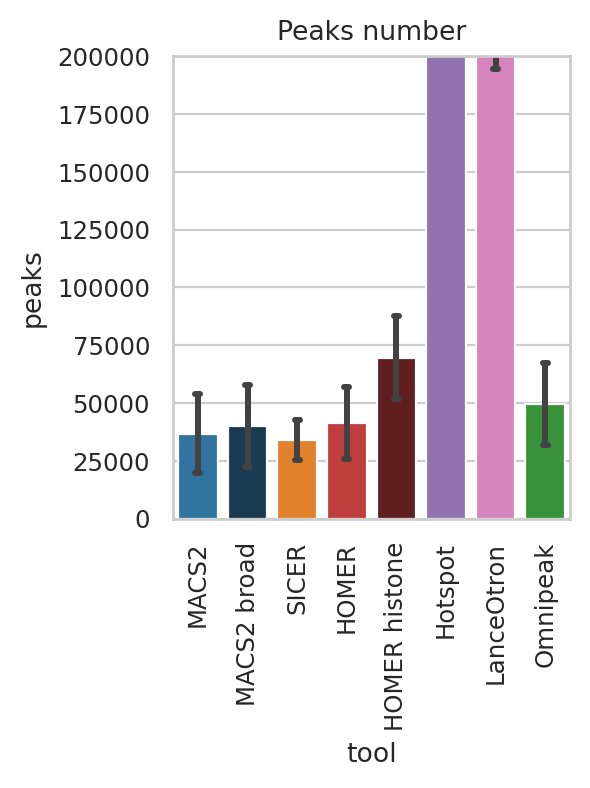

In [654]:
plt.figure(figsize=(3, 4))
ax = plt.axes()
sns.barplot(data=dfa, x='tool', y='peaks',
            order=TOOLS,
            palette=TOOLS_PALETTE,
            errorbar='sd', capsize=.1,
            # err_kws={'linewidth': 2},
            # legend=False,
            ax=ax)
ax.set_ylim(0, 200_000)
plt.xticks(rotation=90)
plt.title('Peaks number')
plt.tight_layout()
plt.tight_layout()
plt.savefig(f'{PATH}/pics/peaks.pdf', bbox_inches='tight', dpi=300)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


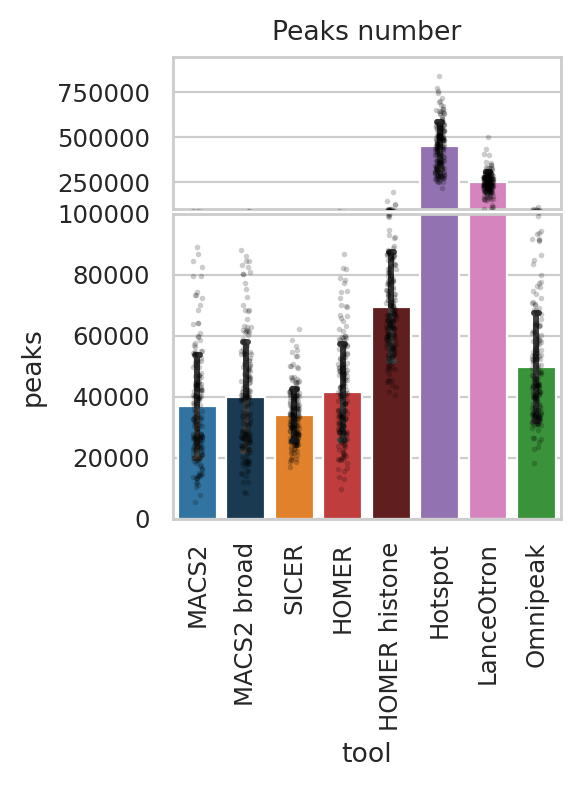

In [655]:
# Set up the matplotlib figure with broken y-axis
f, (axt, ax) = plt.subplots(2, 1, sharex=True, figsize=(2.5, 3),
                            gridspec_kw={'height_ratios': [1, 2]})
for j, axes in enumerate([ax, axt]):
    sns.barplot(data=dfa, x='tool', y='peaks',
                order=TOOLS,
                palette=TOOLS_PALETTE,
                errorbar='sd', capsize=.1,
                ax=axes)
    sns.stripplot(data=dfa, x='tool', y='peaks',
                  order=TOOLS,
                  alpha=0.2, size=2,
                  color='black',
                  ax=axes)
ax.set_ylim(0, 100_000)
axt.set_ylim(100_000, 950_000)
axt.set_xlabel(None)
axt.set_ylabel(None)
ax.xaxis.set_tick_params(rotation=90)
axt.title.set_text('Peaks number')
ax.set_ylabel('peaks')
axt.legend().set_visible(False)
# plt.tight_layout()
plt.subplots_adjust(hspace=0.02)  # Adjust hspace closer to zero to remove spacing
plt.show()

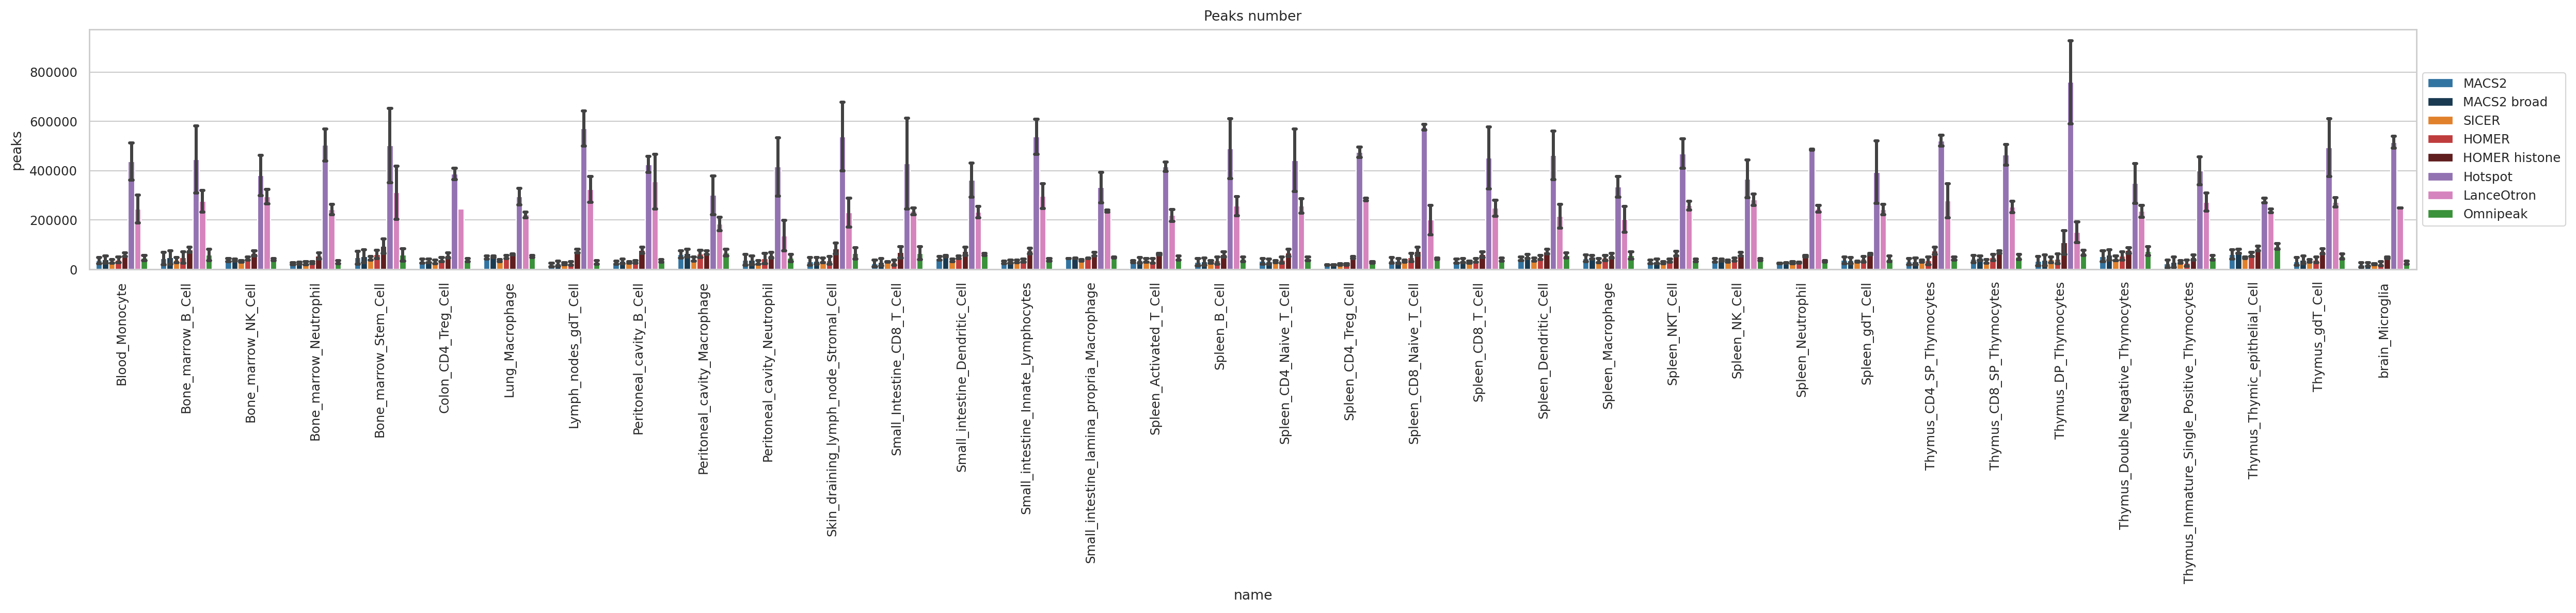

In [656]:
plt.figure(figsize=(25, 6))
g_result = sns.barplot(data=dfa, x='name', y='peaks', hue='tool',
                       hue_order=TOOLS,
                       palette=TOOLS_PALETTE,
                       errorbar='sd', capsize=.05,
                       # err_kws={'linewidth': 2}
                       )
g_result.axes.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=90)
plt.title('Peaks number')
plt.tight_layout()
plt.tight_layout()
plt.savefig(f'{PATH}/pics/peaks.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Lengths

In [657]:
ts = []
for srr, name, tool, file in tqdm(zip(dfa['srr'], dfa['name'], dfa['tool'], dfa['file'])):
    lengths = bedl(file)
    t = pd.DataFrame(dict(length=lengths))
    t = t.sample(min(len(t), 10_000)).copy()
    t['srr'] = srr
    t['name'] = name
    t['tool'] = tool
    ts.append(t)
df_lens = pd.concat(ts).reset_index(drop=True)
del ts
df_lens.sample(10)

0it [00:00, ?it/s]

,length,srr,name,tool
10554599,339,SRR5799503,Spleen_Dendritic_Cell,LanceOtron
817848,500,SRR5799533,Bone_marrow_B_Cell,HOMER histone
8500236,300,SRR5799468,Spleen_B_Cell,Omnipeak
4250186,503,SRR5799529,Peritoneal_cavity_Macrophage,MACS2 broad
5157332,607,SRR5799552,Skin_draining_lymph_node_Stromal_Cell,LanceOtron
13001208,766,SRR5799546,Thymus_DP_Thymocytes,HOMER histone
7120117,197,SRR5799458,Spleen_B_Cell,LanceOtron
8071101,455,SRR5799474,Spleen_B_Cell,MACS2 broad
5497113,56,SRR5799525,Small_intestine_Dendritic_Cell,LanceOtron
11848554,134,SRR5799413,Spleen_NK_Cell,MACS2 broad


In [658]:
print(df_lens['length'].min())
df_lens = df_lens[df_lens['length'] > 0].reset_index(drop=True)

0


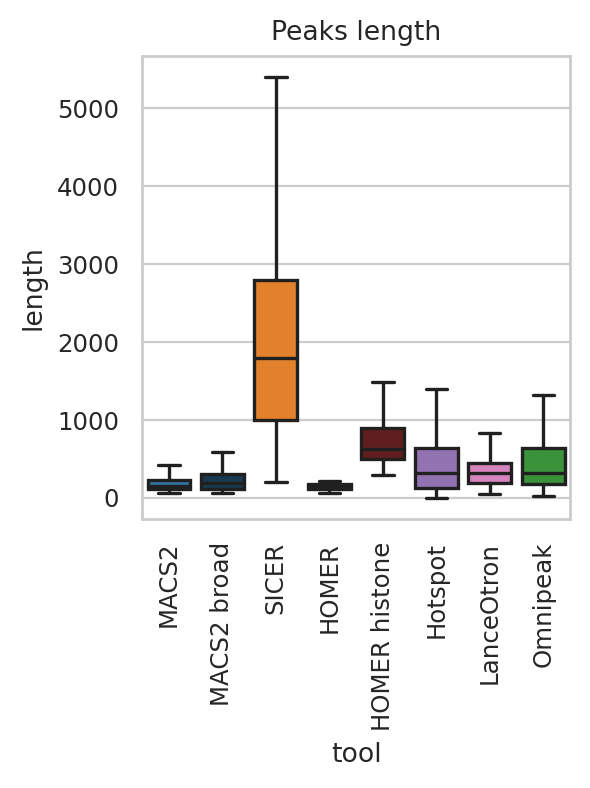

In [659]:
plt.figure(figsize=(3, 4))
g_result = sns.boxplot(data=df_lens, x='tool', y='length',
                       order=TOOLS,
                       palette=TOOLS_PALETTE,
                       showfliers=False)
plt.xticks(rotation=90)
plt.title('Peaks length')
plt.tight_layout()
# plt.savefig(f'{PATH}/pics/peaks_length.pdf', bbox_inches='tight', dpi=300)
plt.show()

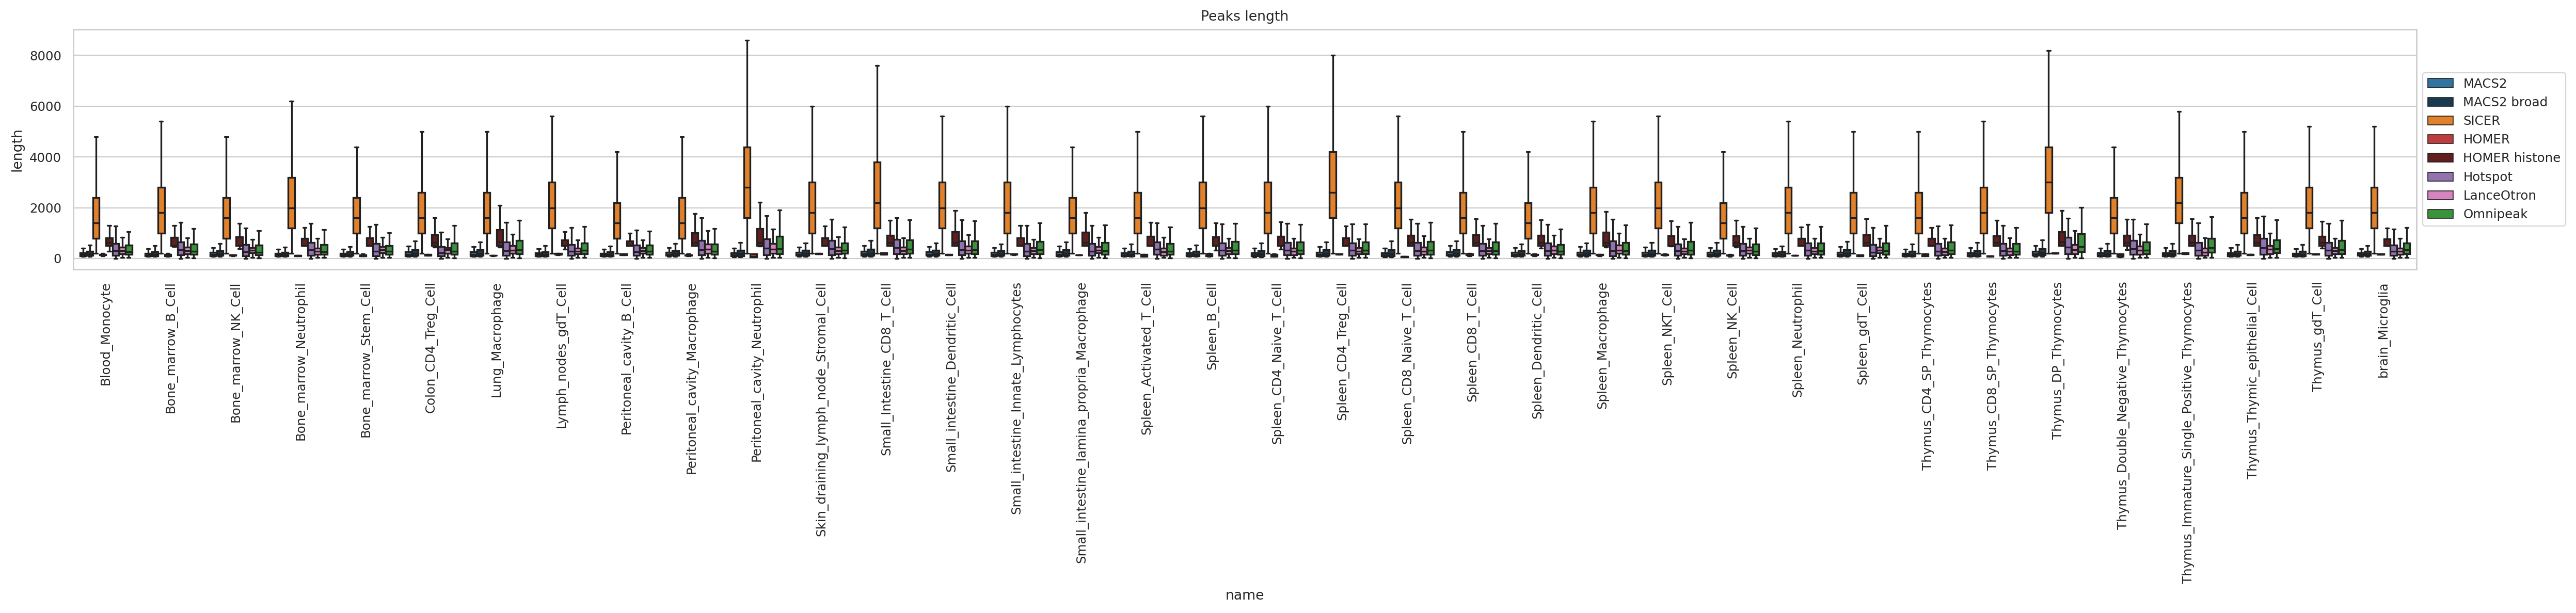

In [660]:
plt.figure(figsize=(25, 6))
g_result = sns.boxplot(data=df_lens, x='name', y='length', hue='tool',
                       hue_order=TOOLS,
                       palette=TOOLS_PALETTE,
                       showfliers=False)
plt.xticks(rotation=90)
plt.title('Peaks length')
g_result.axes.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
# plt.savefig(f'{PATH}/pics/peaks_length.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [661]:
# Compute percentiles
rows = []
for (srr, name, tool), dfl in tqdm(df_lens.groupby(['srr', 'name', 'tool'])):
    for p in [5, 25, 50, 75, 95]:
        rows.append([srr, name, tool, p, np.percentile(dfl['length'], p)])
df_lens_perc = pd.DataFrame(rows, columns=['srr', 'name', 'tool', 'p', 'length'])
df_lens_perc.sample(3)

  0%|          | 0/1478 [00:00<?, ?it/s]

,srr,name,tool,p,length
3943,SRR5799479,Spleen_NKT_Cell,Omnipeak,75,685.00
5685,SRR5799523,Small_intestine_lamina_propria_Macrophage,LanceOtron,5,85.95
309,SRR5799388,Thymus_Double_Negative_Thymocytes,MACS2 broad,95,548.00


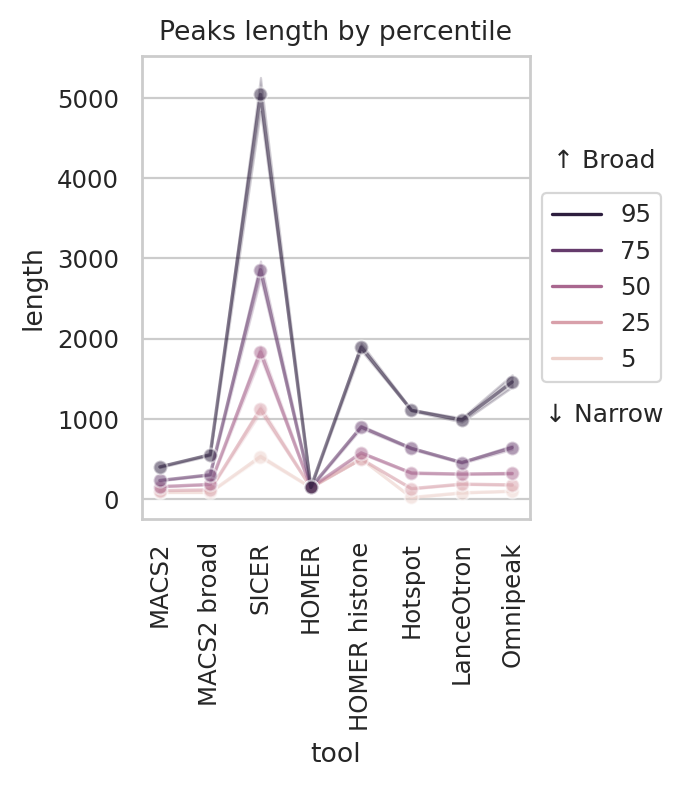

In [662]:
plt.figure(figsize=(3.5, 4))
ax = plt.axes()
df_lens_perc['ti'] = 0
for i, tool in enumerate(TOOLS):
    df_lens_perc.loc[df_lens_perc['tool'] == tool, 'ti'] = i
sns.lineplot(data=df_lens_perc, x='ti', y='length', hue='p',
             alpha=.5, marker='o', markersize=5,
             hue_order=[95, 75, 50, 25, 2],
             ax=ax)
ax.set_xticks(range(8), minor=False)
ax.set_xticklabels(TOOLS)
ax.set_xlabel('tool')
ax.set_ylabel('length')
# Get legend handles and labels
handles, labels = ax.get_legend_handles_labels()
# Update legend with new labels
ax.legend(list(reversed(handles)), list(reversed(labels)), loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=90)
plt.title('Peaks length by percentile')
ax.text(1.06, 0.8, "↑ Broad",
        transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=1))
ax.text(1.04, 0.25, "↓ Narrow",
        transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=1))

ax.xaxis.grid(False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2559296/1265628972.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_footprint = df_lens.groupby(['srr', 'tool']).agg('sum').reset_index()


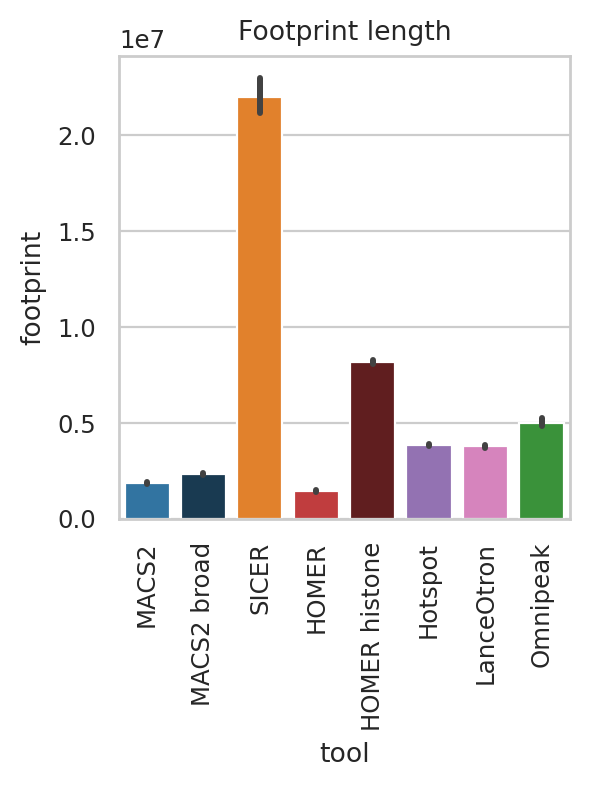

In [663]:
# Footprint
df_footprint = df_lens.groupby(['srr', 'tool']).agg('sum').reset_index()
plt.figure(figsize=(3, 4))
ax = plt.axes()
sns.barplot(data=df_footprint, x='tool', y='length',
            order=TOOLS,
            palette=TOOLS_PALETTE,
            ax=ax)
ax.set_ylabel('footprint')
plt.xticks(rotation=90)
plt.title('Footprint length')
plt.tight_layout()
plt.show()

In [664]:
# Average length
def compute_avg_lens(df):
    ts = []
    for (srr, tool), dft in df[
        ['srr', 'tool', 'length']
    ].groupby(['srr', 'tool']):
        dft.sort_values(by=['length'], inplace=True)
        ts.append(dft.iloc[int(len(dft) * 0.1): int(len(dft) * 0.9)])
    ts = pd.concat(ts).reset_index(drop=True)
    df_lens_avg = ts.groupby(['srr', 'tool']).agg('mean').reset_index()
    return df_lens_avg

In [665]:
df_lens_avg = compute_avg_lens(df_lens)

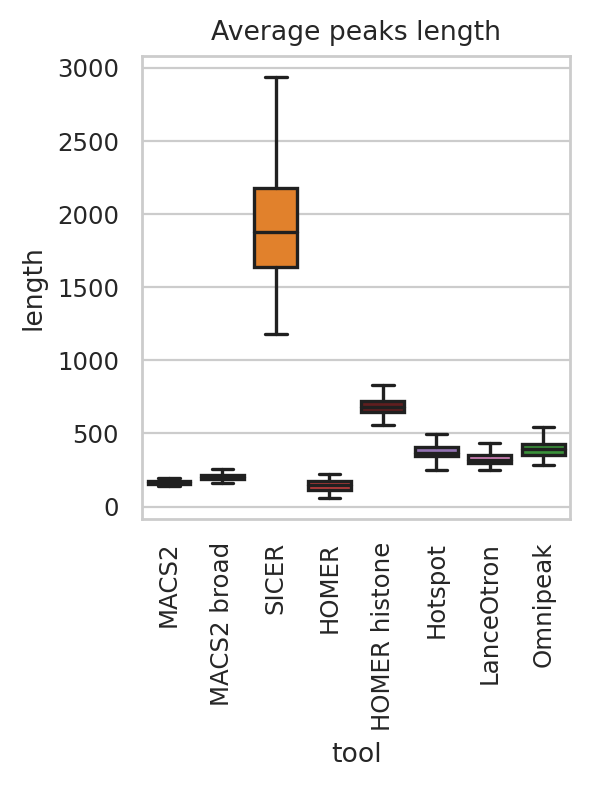

In [666]:
plt.figure(figsize=(3, 4))
ax = plt.axes()
sns.boxplot(data=df_lens_avg, x='tool', y='length',
            order=TOOLS,
            palette=TOOLS_PALETTE,
            showfliers=False,
            ax=ax)
# ax.set(yscale='log')
plt.xticks(rotation=90)
plt.title('Average peaks length')
plt.tight_layout()
plt.show()

# Jaccard overlap

In [667]:
import pyranges as pr


def load(f):
    peaks = lines(f)
    if peaks == 0:
        return pr.PyRanges(), 0, 0
    else:
        prf = pr.read_bed(f)
        return prf, peaks, prf.lengths().sum()


def compute_overlaps(df):
    dfoverlap = pd.DataFrame(columns=['name', 'tool', 'file1', 'file2',
                                      'peaks1', 'peaks2', 'overlap12', 'overlap21',
                                      'peaks1_len', 'peaks2_len', 'overlap_len'], dtype=object)
    for (name, tool), dft in tqdm(list(df.groupby(['name', 'tool']))):
        print('Processing', name, tool, len(dft))
        if len(dft) < 2:
            continue
        files = list(dft['file'])
        ranges = [None] * len(files)
        peaks = [-1] * len(files)
        peaks_lens = [-1] * len(files)
        print('Loading...')
        for i, file in enumerate(files):
            ranges[i], peaks[i], peaks_lens[i] = load(sorted_file(file))
        print('Computing...')
        for i, j in product(range(len(ranges)), range(len(ranges))):
            if i >= j:
                continue
            file1, file2 = files[i], files[j]
            ranges1, ranges2 = ranges[i], ranges[j]
            peaks1, peaks2 = peaks[i], peaks[j]
            peaks1_len, peaks2_len = peaks_lens[i], peaks_lens[j]
            if peaks1 <= 0 or peaks2 <= 0:
                dfoverlap.loc[len(dfoverlap)] = (name, tool, file1, file2,
                                                 peaks1, peaks2, 0, 0,
                                                 peaks1_len, peaks2_len, 0)
                continue
            overlap1 = len(ranges1.overlap(ranges2))
            overlap2 = len(ranges2.overlap(ranges1))
            overlap_len = ranges1.intersect(ranges2).lengths().sum()
            dfoverlap.loc[len(dfoverlap)] = (name, tool, file1, file2,
                                             peaks1, peaks2, overlap1, overlap2,
                                             peaks1_len, peaks2_len, overlap_len)
    return dfoverlap

In [668]:
df_overlap_path = f'{PATH}/df_overlap.tsv'
df_overlap = load_or_compute(df_overlap_path, lambda: compute_overlaps(dfa))

In [669]:
df_overlap['jaccard'] = [
    d(lo, l1 + l2 - lo)
    for l1, l2, lo in zip(df_overlap['peaks1_len'], df_overlap['peaks2_len'], df_overlap['overlap_len'])
]
df_overlap.sort_values(by='name', inplace=True)

Jaccard


/tmp/ipykernel_2559296/1265442344.py:14: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=df_overlap,


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

LanceOtron vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:7.122e-183 U_stat=3.466e+04
Hotspot vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.387e-196 U_stat=2.759e+04
HOMER histone vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:7.292e-33 U_stat=1.740e+05
HOMER vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:9.151e-107 U_stat=9.225e+04
SICER vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.669e-48 U_stat=1.524e+05


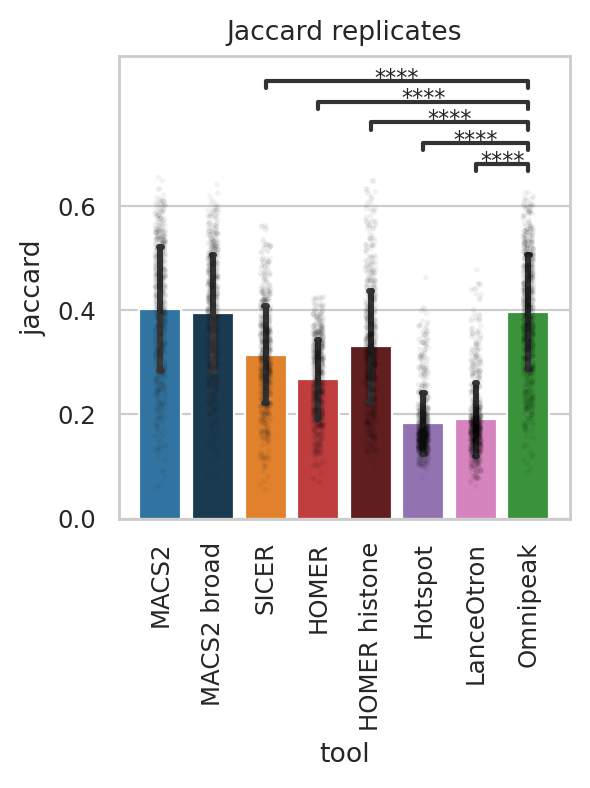

In [670]:
print('Jaccard')

plt.figure(figsize=(3, 4))
ax = plt.axes()
sns.barplot(data=df_overlap,
            x='tool', y='jaccard',
            order=TOOLS,
            # legend=False,
            dodge=False,
            palette=TOOLS_PALETTE,
            errorbar='sd', capsize=.05,
            # err_kws={'linewidth': 2}
            ax=ax)
sns.stripplot(data=df_overlap,
              x='tool', y='jaccard',
              order=TOOLS,
              dodge=False, size=2, color="black", alpha=0.05, palette='dark:black',
              legend=False,
              ax=ax)

plt.xticks(rotation=90)
plt.title('Jaccard replicates')

pairs = [(tool, 'Omnipeak') for tool in TOOLS if tool != 'Omnipeak']  # which groups to compare
annot = Annotator(ax, pairs, data=df_overlap, x='tool', y='jaccard', order=TOOLS, )
annot.configure(test='Mann-Whitney', comparisons_correction="BH", correction_format="replace",
                hide_non_significant=True,
                verbose=2,
                text_offset=-3, line_offset=0)
annot.apply_test()
annot.annotate()

ax.set_yticks([0.2 * i for i in range(4)], minor=False)

plt.tight_layout()
plt.savefig(f'{PATH}/pics/jaccard.pdf', bbox_inches='tight', dpi=300)
plt.show()

Jaccard


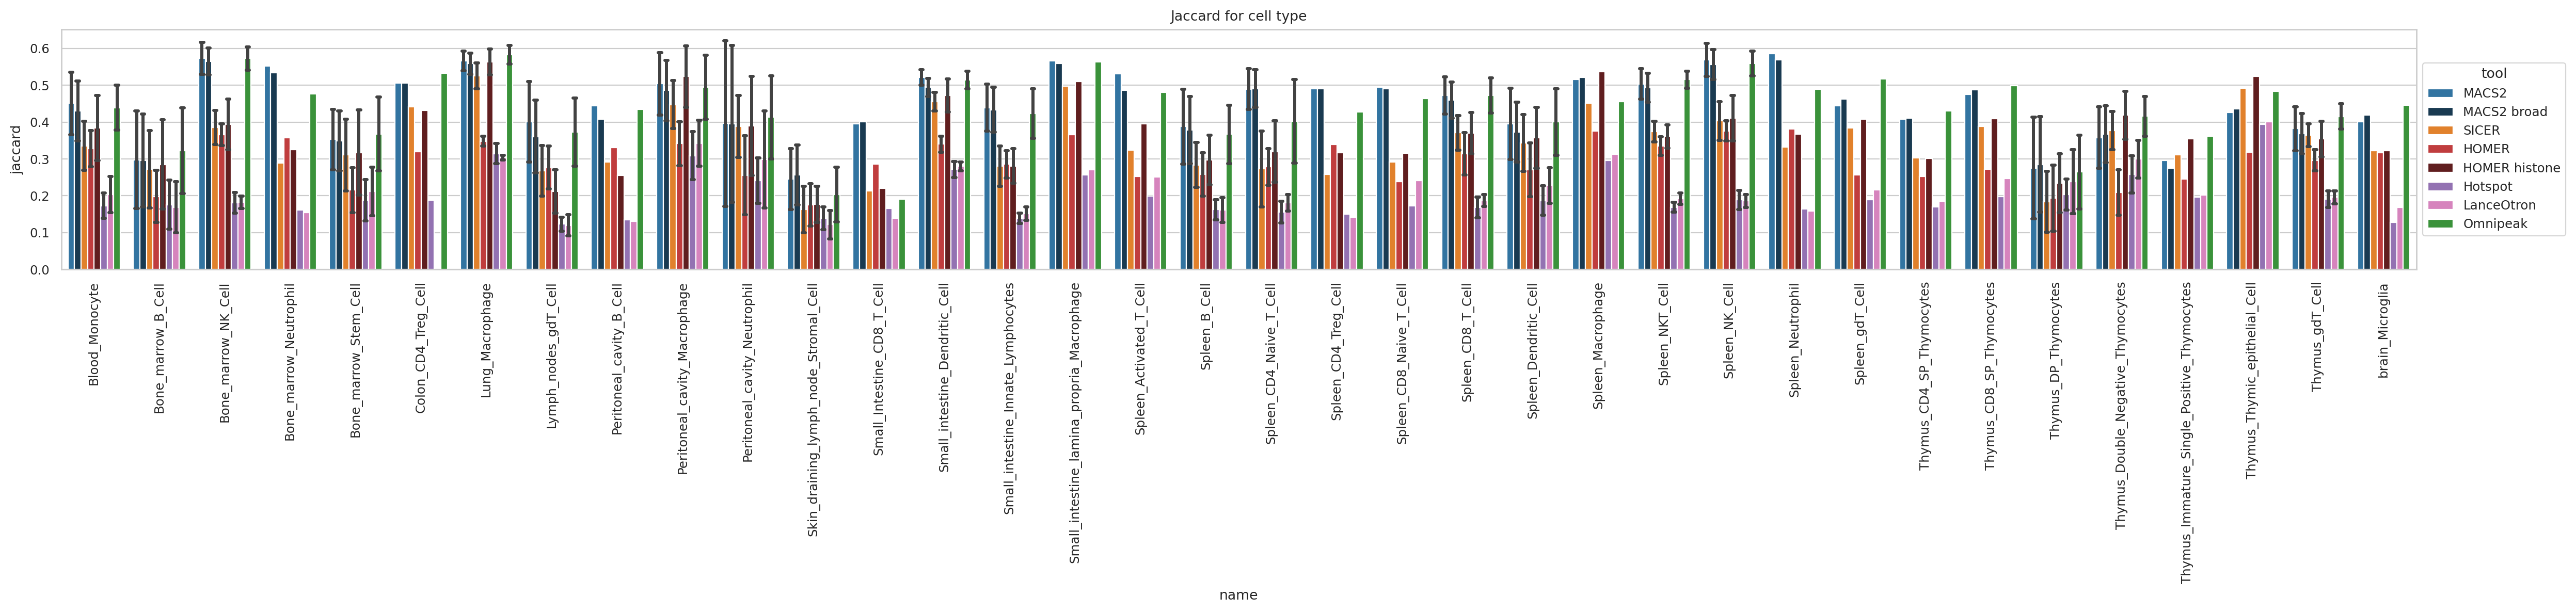

In [671]:
print('Jaccard')

plt.figure(figsize=(25, 6))
ax = plt.axes()
sns.barplot(data=df_overlap,
            x='name', y='jaccard',
            hue='tool',
            hue_order=TOOLS,
            dodge=True,
            palette=TOOLS_PALETTE,
            errorbar='sd', capsize=.05,
            # err_kws={'linewidth': 2},
            ax=ax)
plt.xticks(rotation=90)
plt.title('Jaccard for cell type')
sns.move_legend(ax, loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig(f'{PATH}/pics/jaccard.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Jaccard vs peaks number

In [672]:
df_overlap.sample(3)

,name,tool,file1,file2,peaks1,peaks2,overlap12,overlap21,peaks1_len,peaks2_len,overlap_len,jaccard
1628,Skin_draining_lymph_node_Stromal_Cell,SICER,/home/jetbrains/data/2024_Immgen/sicer/SRR5799...,/home/jetbrains/data/2024_Immgen/sicer/SRR5799...,27325,36220,13833,14170,77077675,71919380,19600276,0.151474
367,Bone_marrow_B_Cell,LanceOtron,/home/jetbrains/data/2024_Immgen/lanceotron/SR...,/home/jetbrains/data/2024_Immgen/lanceotron/SR...,331043,343371,71973,72333,103374958,105807455,18769949,0.098575
1580,Skin_draining_lymph_node_Stromal_Cell,MACS2 broad,/home/jetbrains/data/2024_Immgen/macs2/SRR5799...,/home/jetbrains/data/2024_Immgen/macs2/SRR5799...,50126,29007,15899,16111,12936138,6856442,3594589,0.221916


In [673]:
rows = []
for tool, file1, file2, jaccard in tqdm(zip(df_overlap['tool'],
                                            df_overlap['file1'],
                                            df_overlap['file2'],
                                            df_overlap['jaccard'])):
    rows.append((tool, file1, jaccard))
    rows.append((tool, file2, jaccard))
t = pd.DataFrame(rows, columns=['tool', 'file', 'jaccard'])
df_jaccard_avg = t.groupby(['tool', 'file']).mean().reset_index()
df_jaccard_avg.sample(3)

0it [00:00, ?it/s]

,tool,file,jaccard
896,MACS2,/home/jetbrains/data/2024_Immgen/macs2/SRR5799...,0.401476
795,MACS2,/home/jetbrains/data/2024_Immgen/macs2/SRR5799...,0.479117
710,LanceOtron,/home/jetbrains/data/2024_Immgen/lanceotron/SR...,0.228571


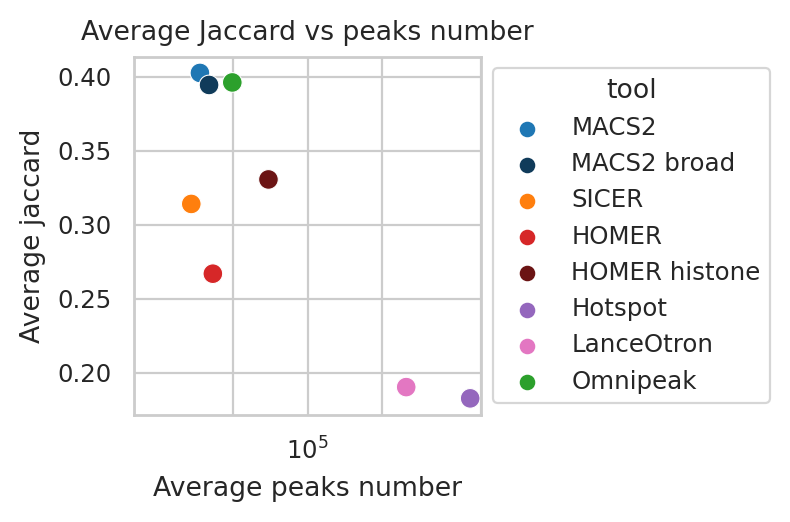

In [752]:
# Average peaks number vs average jaccard
t1 = dfa[['tool', 'peaks']].groupby(['tool']).mean().reset_index()
t2 = df_overlap[['tool', 'jaccard']].groupby(['tool']).mean().reset_index()
avg_peaks_jaccard = pd.merge(t1, t2, on='tool')

plt.figure(figsize=(4, 2.7))
ax = plt.axes()
sns.scatterplot(
    avg_peaks_jaccard, x='peaks', y='jaccard',
    hue='tool',
    hue_order=TOOLS,
    palette=TOOLS_PALETTE,
    marker='o',
    ax=ax)

ax.set_xlabel('Average peaks number')
ax.set_ylabel('Average jaccard')
ax.title.set_text('Average Jaccard vs peaks number')
sns.move_legend(ax, loc='center left', bbox_to_anchor=(1, 0.5))
ax.collections[0].set_sizes([50])
ax.set_xlim(2e4, 5e5)
ax.set(xscale='log')
ax.set_xticks([2e4, 5e4, 1e5, 2e5, 5e5])
plt.tight_layout()
plt.show()

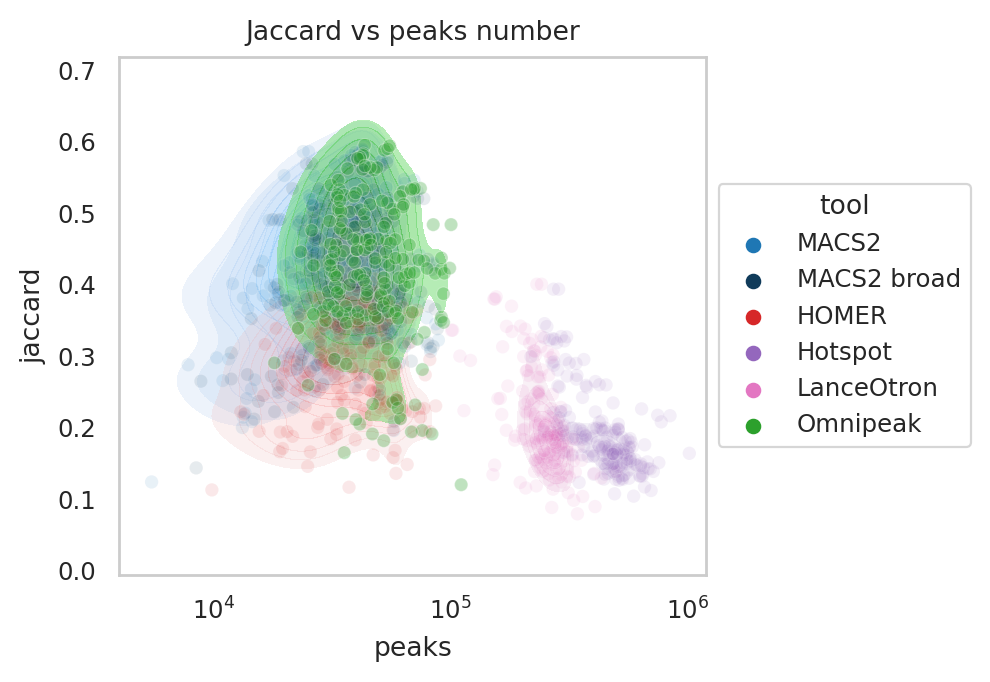

In [761]:
t = pd.merge(dfa[['file', 'tool', 'peaks']], df_jaccard_avg, on=['file', 'tool']).reset_index()
t = t[t['tool'].isin(set(TOOLS_LIMITED))]

plt.figure(figsize=(5, 3.5))
ax = plt.axes()
sns.kdeplot(t[t['tool'] != 'Omnipeak'],
            hue='tool',
            hue_order=TOOLS_LIMITED,
            palette=TOOLS_PALETTE,
            x='peaks', y='jaccard',
            alpha=0.2,
            thresh=0.2,
            fill=True,
            legend=False,
            ax=ax)
sns.kdeplot(t[t['tool'] == 'Omnipeak'],
            hue='tool',
            hue_order=TOOLS_LIMITED,
            palette=TOOLS_PALETTE,
            x='peaks', y='jaccard',
            alpha=0.5,
            thresh=0.2,
            fill=True,
            legend=False,
            ax=ax)
sns.scatterplot(
    t[t['tool'] != 'Omnipeak'], x='peaks', y='jaccard',
    hue='tool',
    hue_order=TOOLS_LIMITED,
    palette=TOOLS_PALETTE,
    alpha=0.1,
    legend=False,
    ax=ax)
sns.scatterplot(
    t[t['tool'] == 'Omnipeak'], x='peaks', y='jaccard',
    hue='tool',
    hue_order=TOOLS_LIMITED,
    alpha=0.3,
    palette=TOOLS_PALETTE,
    ax=ax)
# sns.scatterplot(
#     avg_peaks_jaccard[avg_peaks_jaccard['tool'].isin(set(TOOLS_LIMITED))], x='peaks', y='jaccard',
#     hue='tool',
#     hue_order=TOOLS_LIMITED,
#     palette=TOOLS_PALETTE,
#     # alpha=0.5,
#     marker='8',
#     legend=False,
#     ax=ax,
# )
# ax.collections[-1].set_sizes([50])

ax.title.set_text('Jaccard vs peaks number')
sns.move_legend(ax, loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_xlim(4e3, 1.2e6)
ax.set(xscale='log')
ax.grid(False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2559296/838612822.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


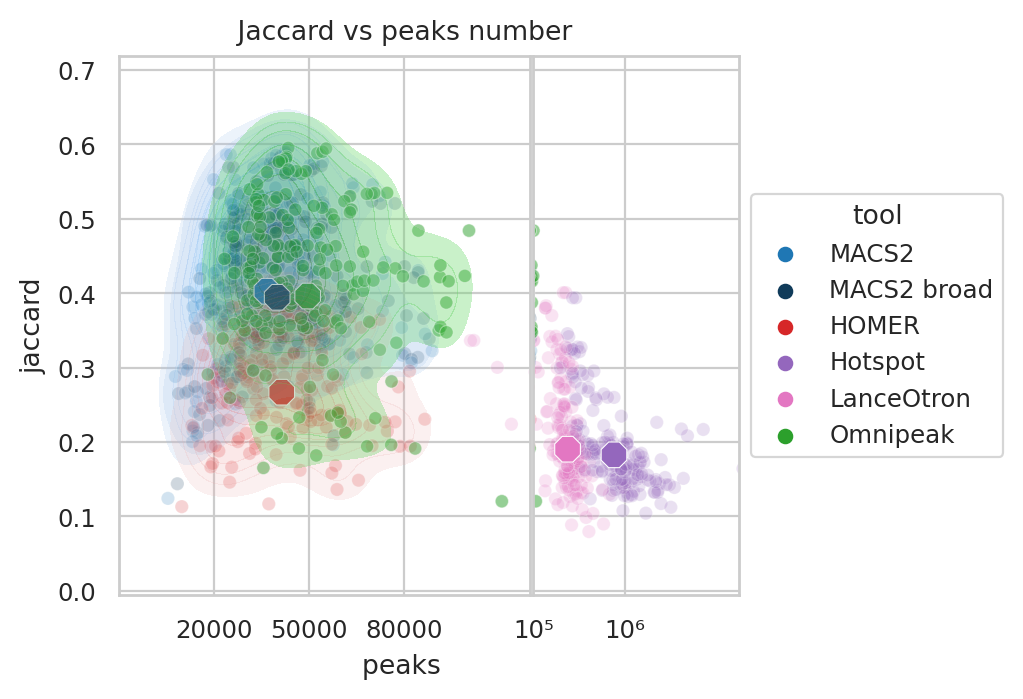

In [740]:
t = pd.merge(dfa[['file', 'tool', 'peaks']], df_jaccard_avg, on=['file', 'tool']).reset_index()
t = t[t['tool'].isin(set(TOOLS_LIMITED))]

# Set up the matplotlib figure with broken y-axis
f, (ax, axr) = plt.subplots(1, 2, sharey=True, figsize=(4, 3.5),
                            gridspec_kw=dict(wspace=0.01, width_ratios=[2, 1]))
for j, axes in enumerate([ax, axr]):
    sns.kdeplot(t[t['tool'] != 'Omnipeak'],
                hue='tool',
                hue_order=TOOLS_LIMITED,
                palette=TOOLS_PALETTE,
                x='peaks', y='jaccard',
                alpha=0.1,
                thresh=0.1,
                fill=True,
                legend=False,
                ax=ax)
    sns.kdeplot(t[t['tool'] == 'Omnipeak'],
                hue='tool',
                hue_order=TOOLS_LIMITED,
                palette=TOOLS_PALETTE,
                x='peaks', y='jaccard',
                alpha=0.2,
                thresh=0.1,
                fill=True,
                legend=False,
                ax=ax)
    sns.scatterplot(
        t[t['tool'] != 'Omnipeak'], x='peaks', y='jaccard',
        hue='tool',
        hue_order=TOOLS_LIMITED,
        alpha=0.2,
        palette=TOOLS_PALETTE,
        legend=False,
        ax=axes)
    sns.scatterplot(
        t[t['tool'] == 'Omnipeak'], x='peaks', y='jaccard',
        hue='tool',
        hue_order=TOOLS_LIMITED,
        alpha=0.5,
        palette=TOOLS_PALETTE,
        legend=j == 1,
        ax=axes)
    sns.scatterplot(
        avg_peaks_jaccard[avg_peaks_jaccard['tool'].isin(set(TOOLS_LIMITED))],
        x='peaks', y='jaccard',
        hue='tool',
        hue_order=TOOLS_LIMITED,
        alpha=1,
        marker='8',
        palette=TOOLS_PALETTE,
        legend=False,
        ax=axes,
    )
    axes.collections[-1].set_sizes([100])

ax.set_xlim(-10_000, 120_000)
axr.set_xlim(100_000, 1_000_000)
ax.set_xticks([20_000, 50_000, 80_000])
axr.set_xticks([100_000, 500_000], ['10⁵', '10⁶'])
# For alignment
ax.set_title('                   Jaccard vs peaks number')
ax.set_xlabel('                  peaks')
axr.set_xlabel(None)
sns.move_legend(axr, loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# Overlap with DHS

In [678]:
DHS_PATH = f'{PATH}/ENCFF754WCT_mm10_dhs_representative_sites.bed'
dhs_file, dhs_peaks, dhs_len = load(sorted_file(DHS_PATH))

df_mm10 = pd.read_csv(f'{PATH}/mm10.chrom.sizes', header=None, sep='\t',
                      names=['chrom', 'len'])
df_mm10['len'] = df_mm10['len'].astype(int)
mm10_len = df_mm10['len'].sum()

print(f'DHS peaks: {dhs_peaks}, DHS len: {dhs_len}, '
      f'Genome fraction: {dhs_len / mm10_len:.2f}')

DHS peaks: 1192301, DHS len: 311395372, Genome fraction: 0.11


In [679]:
from itertools import product


def compute_dhs_overlaps(df):
    dhs_file, dhs_peaks, dhs_len = load(sorted_file(DHS_PATH))
    dfoverlap = pd.DataFrame(
        columns=['srr', 'name', 'tool', 'file', 'way', 'peaks', 'overlap', 'len', 'overlap_len'], dtype=object)
    for (srr, name, tool), dft in tqdm(list(df.groupby(['srr', 'name', 'tool']))):
        print('Processing', srr, name, tool, len(dft))
        for f in dft['file']:
            file, peaks, peaks_len = load(sorted_file(f))
            overlap_len = file.intersect(dhs_file).lengths().sum()
            owd = len(file.overlap(dhs_file))
            dfoverlap.loc[len(dfoverlap)] = (srr, name, tool, f, 'with_dhs', peaks, owd, peaks_len, overlap_len)
            odw = len(dhs_file.overlap(file))
            dfoverlap.loc[len(dfoverlap)] = (srr, name, tool, f, 'dhs_with', dhs_peaks, odw, dhs_len, overlap_len)
    return dfoverlap

In [680]:
dhs_overlap_path = f'{PATH}/dhs_overlap.tsv'
dhs_overlap = load_or_compute(dhs_overlap_path, lambda: compute_dhs_overlaps(dfa))
dhs_overlap.sample(3)

,srr,name,tool,file,way,peaks,overlap,len,overlap_len
1449,SRR5799471,Bone_marrow_B_Cell,Omnipeak,/home/jetbrains/data/2024_Immgen/omnipeak/SRR5...,dhs_with,1192301,40185,311395372,8019646
1759,SRR5799491,Blood_Monocyte,HOMER histone,/home/jetbrains/data/2024_Immgen/homer/SRR5799...,dhs_with,1192301,112997,311395372,26627291
984,SRR5799442,Spleen_CD8_T_Cell,Omnipeak,/home/jetbrains/data/2024_Immgen/omnipeak/SRR5...,with_dhs,31233,29538,12498634,9299915


In [681]:
dhs_overlap['overlap_share'] = [o / p if p > 0 else 0 for o, p in zip(dhs_overlap['overlap'], dhs_overlap['peaks'])]
dhs_overlap['overlap_len_share'] = [o / p if p > 0 else 0 for o, p in
                                    zip(dhs_overlap['overlap_len'], dhs_overlap['len'])]
dhs_overlap.sample(3)

,srr,name,tool,file,way,peaks,overlap,len,overlap_len,overlap_share,overlap_len_share
2432,SRR5799533,Bone_marrow_B_Cell,Hotspot,/home/jetbrains/data/2024_Immgen/hotspot/SRR57...,with_dhs,352343,170936,135898373,51125552,0.485141,0.376204
1790,SRR5799493,Blood_Monocyte,HOMER histone,/home/jetbrains/data/2024_Immgen/homer/SRR5799...,with_dhs,54064,51116,47655729,26267451,0.945472,0.551192
2012,SRR5799507,Skin_draining_lymph_node_Stromal_Cell,HOMER,/home/jetbrains/data/2024_Immgen/homer/SRR5799...,with_dhs,31292,28445,6258303,5025838,0.909018,0.803067


## by counts

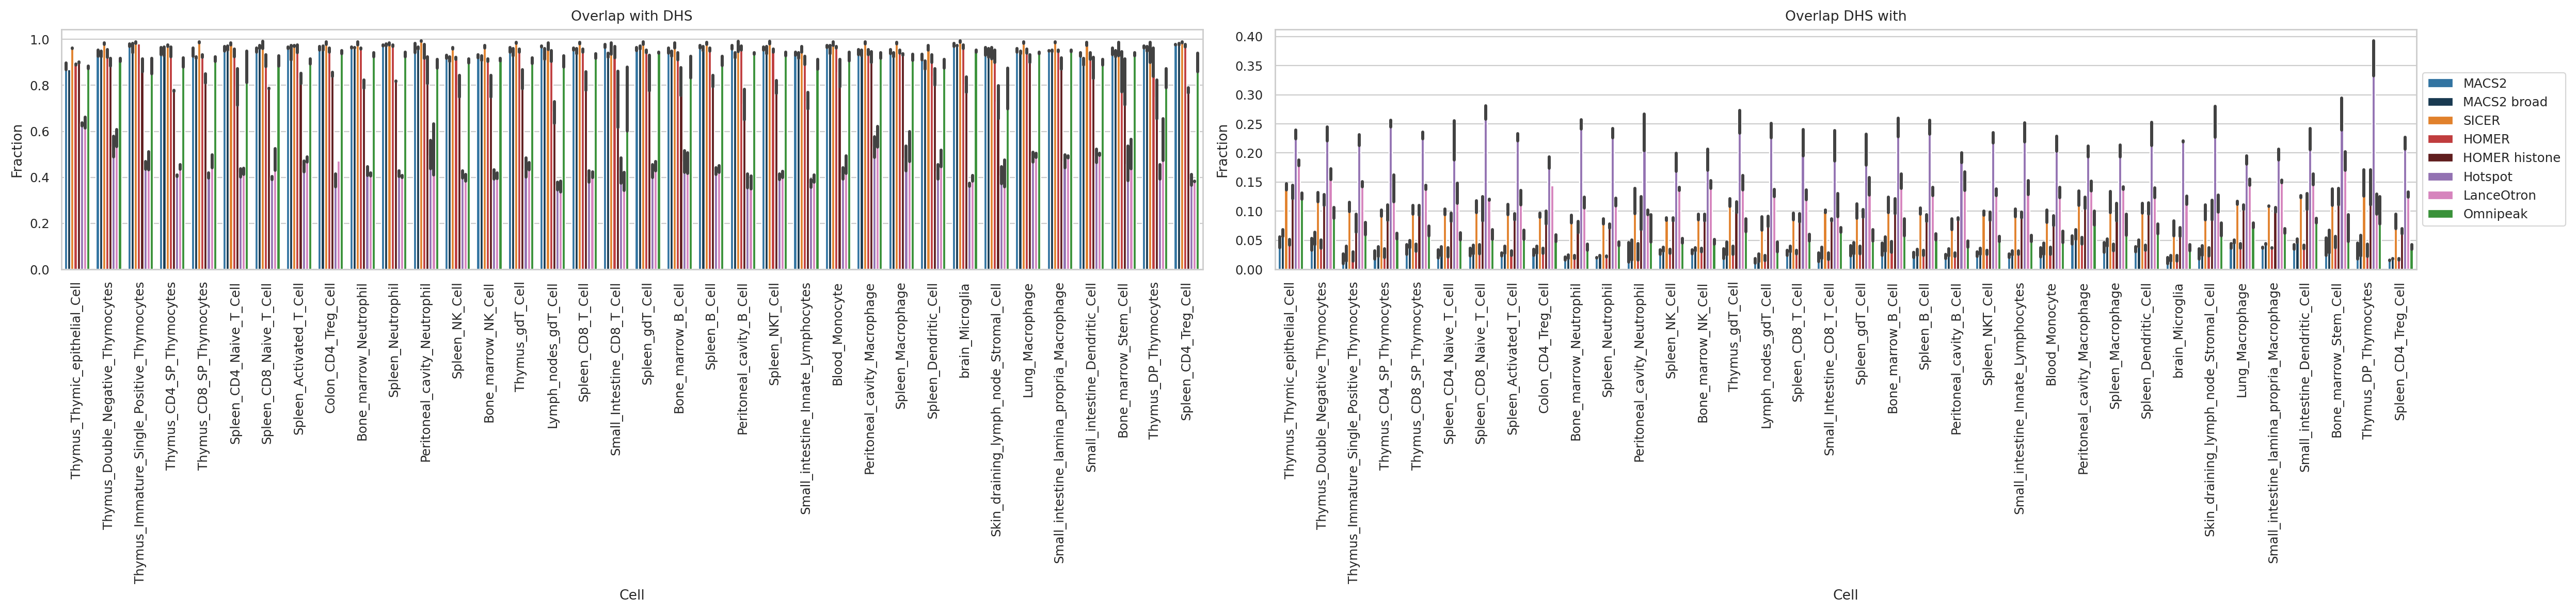

In [682]:
plt.figure(figsize=(25, 6))
# Plot 
ax = plt.subplot(1, 2, 1)
ax.title.set_text('Overlap with DHS')
sns.barplot(data=dhs_overlap[dhs_overlap['way'] == 'with_dhs'], x='name', y='overlap_share', hue='tool',
            hue_order=TOOLS,
            palette=TOOLS_PALETTE,
            # errorbar='sd', capsize=.05, err_kws={'linewidth': 2},
            ax=ax)
ax.xaxis.set_tick_params(rotation=90)
ax.set_xlabel('Cell')
ax.set_ylabel('Fraction')
ax.legend(loc='lower left', title='tool')
ax.legend().set_visible(False)

ax = plt.subplot(1, 2, 2)
ax.title.set_text('Overlap DHS with')
t = dhs_overlap[dhs_overlap['way'] == 'dhs_with'].copy()
t['overlap'].clip(upper=0.15, inplace=True)
sns.barplot(data=t, x='name', y='overlap_share', hue='tool',
            hue_order=TOOLS,
            palette=TOOLS_PALETTE,
            # errorbar='sd', capsize=.05, err_kws={'linewidth': 2},
            ax=ax)
ax.xaxis.set_tick_params(rotation=90)
ax.set_xlabel('Cell')
ax.set_ylabel('Fraction')
ax.legend(loc='lower left', title='tool')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.savefig(f'{PATH}/pics/dhs.pdf', bbox_inches='tight', dpi=300)
plt.show()

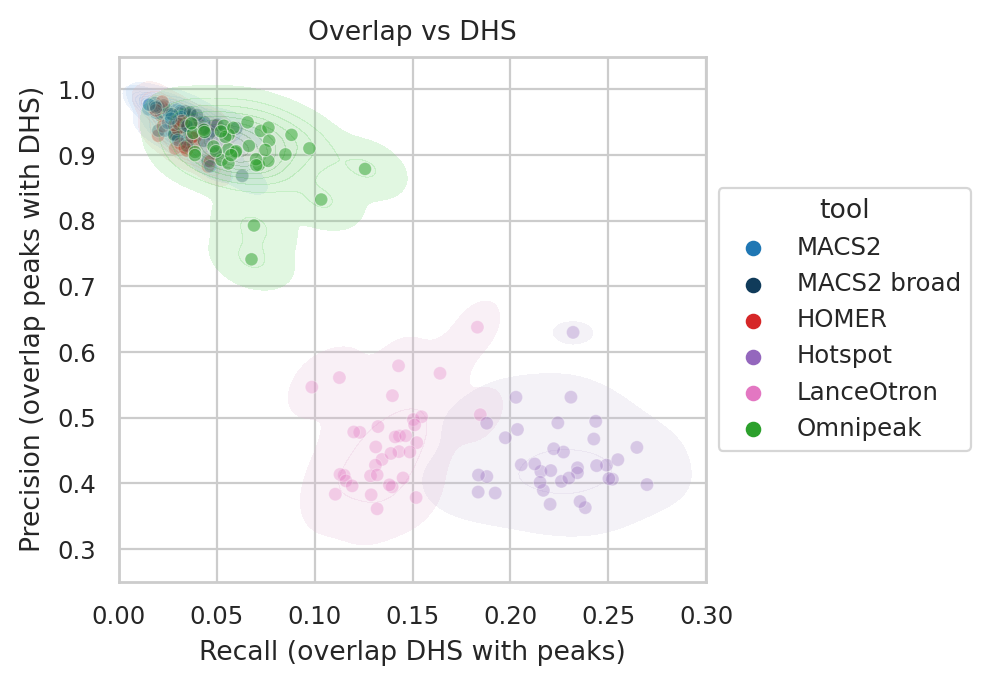

In [790]:
t = pd.pivot_table(dhs_overlap[['name', 'tool', 'way', 'overlap_share']],
                   values='overlap_share', columns=['way'], index=['name', 'tool']).reset_index()
t = t[t['tool'].isin(set(TOOLS_LIMITED))]
plt.figure(figsize=(5, 3.5))
ax = plt.axes()
sns.kdeplot(t[t['tool'] != 'Omnipeak'],
            hue='tool',
            hue_order=TOOLS_LIMITED,
            palette=TOOLS_PALETTE,
            x='dhs_with', y='with_dhs',
            alpha=0.2,
            thresh=0.01,
            fill=True,
            legend=False,
            ax=ax)
sns.scatterplot(
    t[t['tool'] != 'Omnipeak'],
    x='dhs_with', y='with_dhs',
    hue='tool',
    hue_order=TOOLS_LIMITED,
    palette=TOOLS_PALETTE,
    alpha=0.3,
    legend=False,
    ax=ax)
sns.kdeplot(t[t['tool'] == 'Omnipeak'],
            x='dhs_with', y='with_dhs',
            hue='tool',
            hue_order=TOOLS_LIMITED,
            palette=TOOLS_PALETTE,
            alpha=0.2,
            thresh=0.01,
            fill=True,
            legend=False,
            ax=ax)
sns.scatterplot(
    t[t['tool'] == 'Omnipeak'],
    x='dhs_with', y='with_dhs',
    hue='tool',
    hue_order=TOOLS_LIMITED,
    palette=TOOLS_PALETTE,
    alpha=0.5,
    ax=ax)

ax.set_xlabel('Recall (overlap DHS with peaks)')
ax.set_ylabel('Precision (overlap peaks with DHS)')
ax.title.set_text('Overlap vs DHS')
sns.move_legend(ax, loc='center left', bbox_to_anchor=(1, 0.5))

# ax.set_yticks(np.arange(0, 0.35, step=0.1), minor=False)
# ax.set_xticks(np.arange(0.3, 1.1, step=0.2), minor=False)
ax.set_xlim(-0.0, 0.3)
ax.set_ylim(0.25, 1.05)

plt.tight_layout()
plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

LanceOtron vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.986e-13 U_stat=1.286e+03
Hotspot vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.046e-13 U_stat=1.296e+03
HOMER vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:7.226e-12 U_stat=3.900e+01
MACS2 broad vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.518e-10 U_stat=9.900e+01
MACS2 vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.783e-12 U_stat=2.700e+01


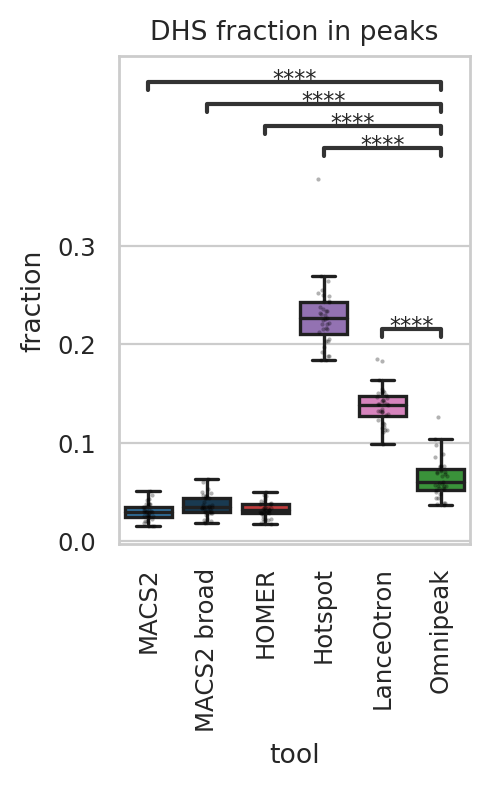

In [799]:
plt.figure(figsize=(2.5, 4))
ax = plt.axes()
ax.title.set_text('DHS fraction in peaks')
sns.boxplot(data=t, x='tool', y='dhs_with',
            showfliers=False,
            order=TOOLS_LIMITED,
            palette=TOOLS_PALETTE,
            ax=ax)
sns.stripplot(data=t, x='tool', y='dhs_with',
              order=TOOLS_LIMITED,
              color='black', alpha=0.3, size=1.5,
              ax=ax)

ax.xaxis.set_tick_params(rotation=90)
ax.set_ylabel('fraction')

pairs = [(tool, 'Omnipeak') for tool in TOOLS_LIMITED if tool != 'Omnipeak']  # which groups to compare
annot = Annotator(ax, pairs, data=t, x='tool', y='dhs_with', order=TOOLS_LIMITED, )
annot.configure(test='Mann-Whitney', comparisons_correction="BH", correction_format="replace",
                hide_non_significant=True,
                verbose=2,
                text_offset=-3, line_offset=0)
annot.apply_test()
annot.annotate()

ax.set_yticks(np.arange(0, 0.35, step=0.1), minor=False)

plt.tight_layout()
plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

LanceOtron vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.046e-13 U_stat=0.000e+00
Hotspot vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.046e-13 U_stat=0.000e+00
HOMER vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.466e-06 U_stat=1.049e+03
MACS2 broad vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.111e-06 U_stat=1.081e+03
MACS2 vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:8.661e-10 U_stat=1.193e+03


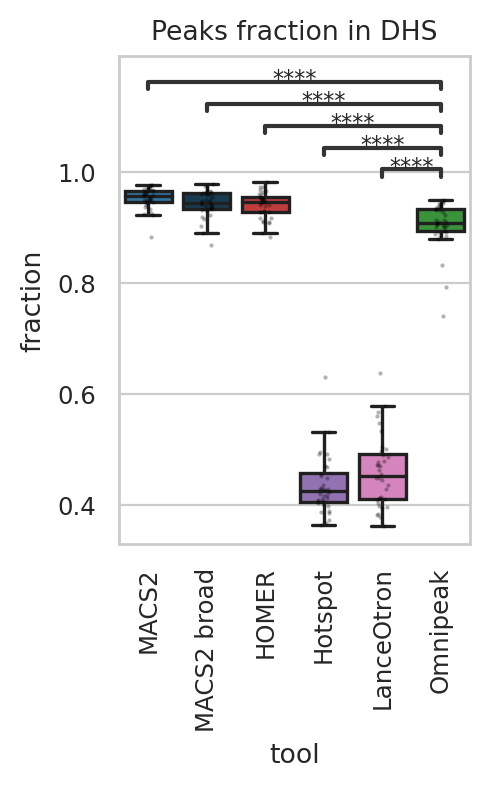

In [798]:
plt.figure(figsize=(2.5, 4))
ax = plt.axes()
ax.title.set_text('Peaks fraction in DHS')
sns.boxplot(data=t, x='tool', y='with_dhs',
            showfliers=False,
            order=TOOLS_LIMITED,
            palette=TOOLS_PALETTE,
            ax=ax)
sns.stripplot(data=t, x='tool', y='with_dhs',
              order=TOOLS_LIMITED,
              color='black', alpha=0.3, size=1.5,
              ax=ax)

ax.xaxis.set_tick_params(rotation=90)
ax.set_ylabel('fraction')

pairs = [(tool, 'Omnipeak') for tool in TOOLS_LIMITED if tool != 'Omnipeak']  # which groups to compare
annot = Annotator(ax, pairs, data=t, x='tool', y='with_dhs', order=TOOLS_LIMITED, )
annot.configure(test='Mann-Whitney', comparisons_correction="BH", correction_format="replace",
                hide_non_significant=True,
                verbose=2,
                text_offset=-3, line_offset=0)
annot.apply_test()
annot.annotate()

ax.set_yticks(np.arange(0.4, 1.05, step=0.2), minor=False)

plt.tight_layout()
plt.show()

## by length

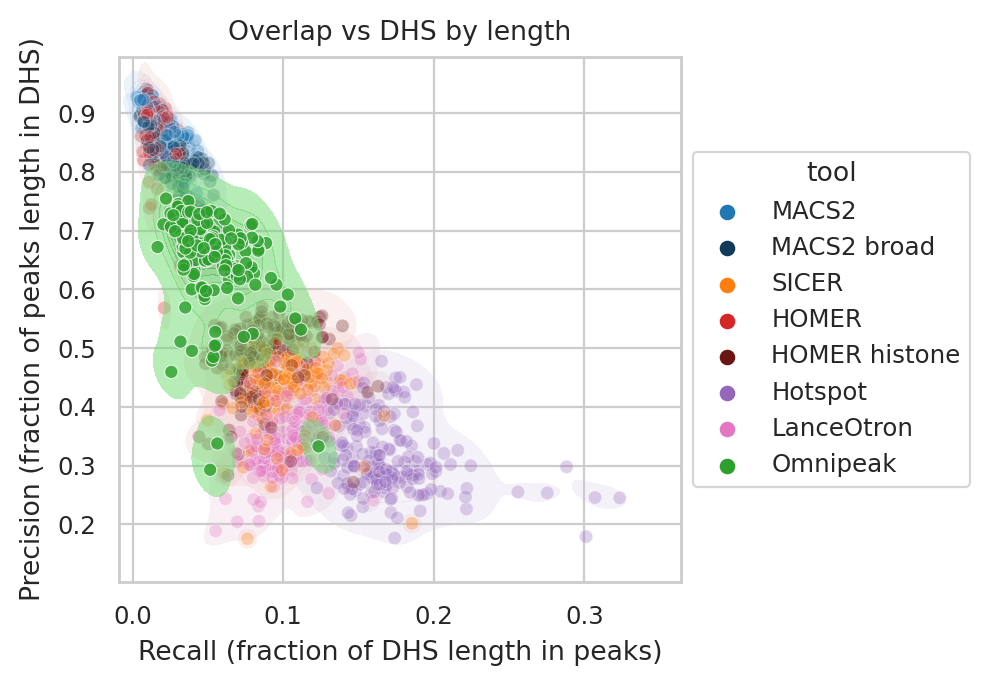

In [805]:
t1 = dhs_overlap[dhs_overlap['way'] == 'with_dhs'].copy()
t1['fraction_in_dhs'] = t1['overlap_len'] / (t1['len'] + 1)
t2 = dhs_overlap[dhs_overlap['way'] == 'dhs_with'].copy()
t2['fraction_in_peaks'] = t2['overlap_len'] / dhs_len

t = pd.merge(t1[['srr', 'tool', 'fraction_in_dhs']],
             t2[['srr', 'tool', 'fraction_in_peaks']], on=['srr', 'tool'], how='inner')

plt.figure(figsize=(5, 3.5))
ax = plt.axes()
sns.kdeplot(t[t['tool'] != 'Omnipeak'],
            hue='tool',
            hue_order=TOOLS,
            palette=TOOLS_PALETTE,
            x='fraction_in_peaks', y='fraction_in_dhs',
            alpha=0.2,
            thresh=0.01,
            fill=True,
            legend=False,
            ax=ax)
sns.scatterplot(
    t[t['tool'] != 'Omnipeak'],
    x='fraction_in_peaks', y='fraction_in_dhs',
    hue='tool',
    hue_order=TOOLS,
    alpha=0.3,
    palette=TOOLS_PALETTE,
    legend=False,
    ax=ax)
sns.kdeplot(t[t['tool'] == 'Omnipeak'],
            hue='tool',
            hue_order=TOOLS,
            palette=TOOLS_PALETTE,
            x='fraction_in_peaks', y='fraction_in_dhs',
            alpha=0.5,
            thresh=0.01,
            fill=True,
            legend=False,
            ax=ax)
sns.scatterplot(
    t[t['tool'] == 'Omnipeak'],
    x='fraction_in_peaks', y='fraction_in_dhs',
    hue='tool',
    hue_order=TOOLS,
    palette=TOOLS_PALETTE,
    alpha=0.8,
    ax=ax)

ax.set_xlabel('Recall (fraction of DHS length in peaks)')
ax.set_ylabel('Precision (fraction of peaks length in DHS)')
ax.title.set_text('Overlap vs DHS by length')
sns.move_legend(ax, loc='center left', bbox_to_anchor=(1, 0.5))

# ax.set_yticks(np.arange(0, 0.35, step=0.1), minor=False)
# ax.set_xticks(np.arange(0.1, 1.1, step=0.2), minor=False)
# ax.set_xlim(0.31, 1.05)
# ax.set_ylim(-0.05, 0.4)

plt.tight_layout()
plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

LanceOtron vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.031e-59 U_stat=3.660e+02
Hotspot vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.600e-60 U_stat=2.310e+02
HOMER vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.026e-60 U_stat=3.391e+04
MACS2 broad vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:7.038e-62 U_stat=3.419e+04
MACS2 vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.863e-62 U_stat=3.422e+04


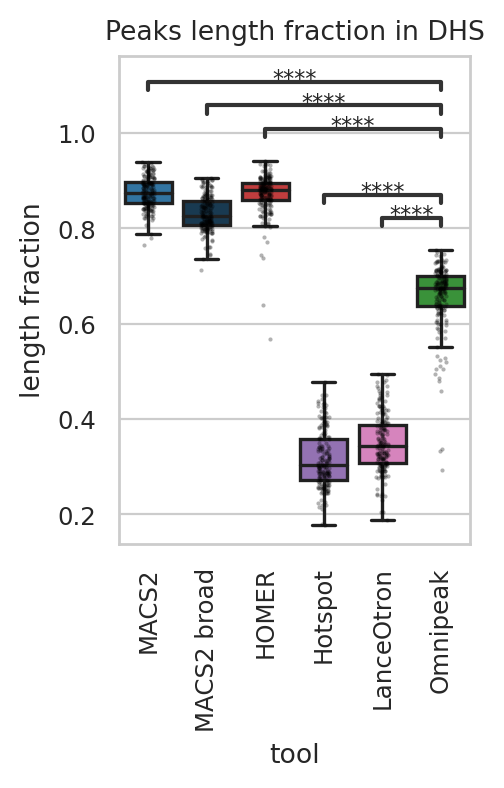

In [806]:
plt.figure(figsize=(2.5, 4))
ax = plt.axes()
ax.title.set_text('Peaks length fraction in DHS')
sns.boxplot(data=t, x='tool', y='fraction_in_dhs',
            showfliers=False,
            order=TOOLS_LIMITED,
            palette=TOOLS_PALETTE,
            ax=ax)
sns.stripplot(data=t, x='tool', y='fraction_in_dhs',
              order=TOOLS_LIMITED,
              color='black', alpha=0.3, size=1.5,
              ax=ax)

ax.xaxis.set_tick_params(rotation=90)
ax.set_ylabel('length fraction')

pairs = [(tool, 'Omnipeak') for tool in TOOLS_LIMITED if tool != 'Omnipeak']  # which groups to compare
annot = Annotator(ax, pairs, data=t, x='tool', y='fraction_in_dhs', order=TOOLS_LIMITED, )
annot.configure(test='Mann-Whitney', comparisons_correction="BH", correction_format="replace",
                hide_non_significant=True,
                verbose=2,
                text_offset=-3, line_offset=0)
annot.apply_test()
annot.annotate()

ax.set_yticks(np.arange(0.2, 1.1, step=0.2), minor=False)

plt.tight_layout()
plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

LanceOtron vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:9.747e-54 U_stat=3.268e+04
Hotspot vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.470e-62 U_stat=3.422e+04
HOMER vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.313e-61 U_stat=1.730e+02
MACS2 broad vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.904e-43 U_stat=2.895e+03
MACS2 vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.342e-55 U_stat=1.014e+03


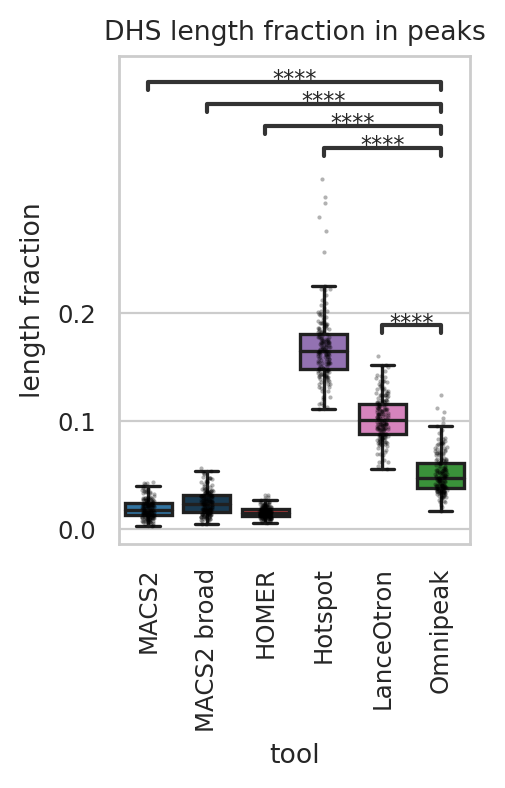

In [802]:
plt.figure(figsize=(2.5, 4))
ax = plt.axes()
ax.title.set_text('DHS length fraction in peaks')
sns.boxplot(data=t, x='tool', y='fraction_in_peaks',
            showfliers=False,
            order=TOOLS_LIMITED,
            palette=TOOLS_PALETTE,
            ax=ax)
sns.stripplot(data=t, x='tool', y='fraction_in_peaks',
              order=TOOLS_LIMITED,
              color='black', alpha=0.3, size=1.5,
              ax=ax)

ax.xaxis.set_tick_params(rotation=90)
ax.set_ylabel('length fraction')

pairs = [(tool, 'Omnipeak') for tool in TOOLS_LIMITED if tool != 'Omnipeak']  # which groups to compare
annot = Annotator(ax, pairs, data=t, x='tool', y='fraction_in_peaks', order=TOOLS_LIMITED, )
annot.configure(test='Mann-Whitney', comparisons_correction="BH", correction_format="replace",
                hide_non_significant=True,
                verbose=2,
                text_offset=-3, line_offset=0)
annot.apply_test()
annot.annotate()

ax.set_yticks(np.arange(0, 0.25, step=0.1), minor=False)

plt.tight_layout()
plt.show()

# Top peaks vs DHS

In [688]:
def how_to_sort(peaks_file, tool):
    if tool.startswith('MACS2'):
        sort_col, ascending = peaks_file.columns[8], False
    elif tool == 'SICER':
        sort_col, ascending = peaks_file.columns[3], False
    elif tool.startswith('HOMER'):
        sort_col, ascending = peaks_file.columns[4], False
    elif tool == 'Hotspot':
        sort_col, ascending = peaks_file.columns[4], False
    elif tool == 'Peakseq':
        sort_col, ascending = peaks_file.columns[8], True
    elif tool == 'LanceOtron':
        sort_col, ascending = peaks_file.columns[4], False
    elif tool == 'Omnipeak':
        sort_col, ascending = peaks_file.columns[8], False
    else:
        sort_col, ascending = peaks_file.columns[4], False
    return sort_col, ascending

In [689]:
def compute_dhs_overlaps_n(df, peaks_min=1000, peaks_max=30_000, peaks_n=10):
    dhs_file, dhs_peaks, dhs_len = load(sorted_file(DHS_PATH))
    rows = []
    for _, (srr, n, tool, file) in tqdm(list(df[['srr', 'name', 'tool', 'file']].iterrows())):
        # print('Processing', n, tool, file)
        peaks_total = lines(file)
        if peaks_total == 0:
            for top in np.linspace(peaks_min, peaks_max, num=peaks_n):
                rows.append((srr, n, tool, int(top), dhs_peaks, file, 0, 0, 0, dhs_len, 0, 0))
            continue
        peaks_file = pr.read_bed(sorted_file10(file), as_df=True)
        sort_col, ascending = how_to_sort(peaks_file, tool)
        peaks_file.sort_values(by=sort_col, ascending=ascending, inplace=True)
        for top in np.linspace(peaks_min, peaks_max, num=peaks_n):
            t = PyRanges(peaks_file.head(int(top)).sort_values(by=['Chromosome', 'Start']))
            peaks = len(t)
            peaks_len = t.lengths().sum()
            ovlp = t.overlap(dhs_file)
            peaks_overlap = len(ovlp)
            overlap_len = ovlp.lengths().sum()
            dhs_overlap = len(dhs_file.overlap(t))
            rows.append((srr, n, tool, int(top), dhs_peaks, file, peaks,
                         peaks_overlap, dhs_overlap, dhs_len, peaks_len, overlap_len))

    df = pd.DataFrame(
        rows,
        columns=['srr', 'name', 'tool', 'top', 'dhs_peaks', 'peaks_file', 'peaks', 'peaks_overlap', 'dhs_overlap',
                 'dhs_len', 'peaks_len', 'overlap_len'],
        dtype=object
    )
    df['jaccard'] = [
        d(o, lp + ld - o)
        for lp, ld, o in zip(df['peaks_len'], df['dhs_len'], df['overlap_len'])
    ]

    return df

In [690]:
dhs_ovlp_path = f'{PATH}/overlap_dhs_n.tsv'
# ! mv {dhs_ovlp_path} {dhs_ovlp_path}.old
dhs_ovlp_df = load_or_compute(dhs_ovlp_path, lambda: compute_dhs_overlaps_n(dfa))
dhs_ovlp_df.sample(3)

,srr,name,tool,top,dhs_peaks,peaks_file,peaks,peaks_overlap,dhs_overlap,dhs_len,peaks_len,overlap_len,jaccard
14623,SRR5799505,brain_Microglia,Omnipeak,10666,1192301,/home/jetbrains/data/2024_Immgen/omnipeak/SRR5...,10666,10623,24940,311395372,8459839,8393450,0.026949
713,SRR5799453,Bone_marrow_B_Cell,Hotspot,10666,1192301,/home/jetbrains/data/2024_Immgen/hotspot/SRR57...,10666,10385,30487,311395372,11679887,11597805,0.037235
12311,SRR5799395,Thymus_CD4_SP_Thymocytes,HOMER,4222,1192301,/home/jetbrains/data/2024_Immgen/homer/SRR5799...,4222,4187,4286,311395372,785292,778782,0.002501


## by counts

In [691]:
dhs_ovlp_df['precision'] = [d(x, y) for x, y in zip(dhs_ovlp_df['peaks_overlap'], dhs_ovlp_df['peaks'])]
dhs_ovlp_df['recall'] = [d(x, y) for x, y in zip(dhs_ovlp_df['dhs_overlap'], dhs_ovlp_df['dhs_peaks'])]

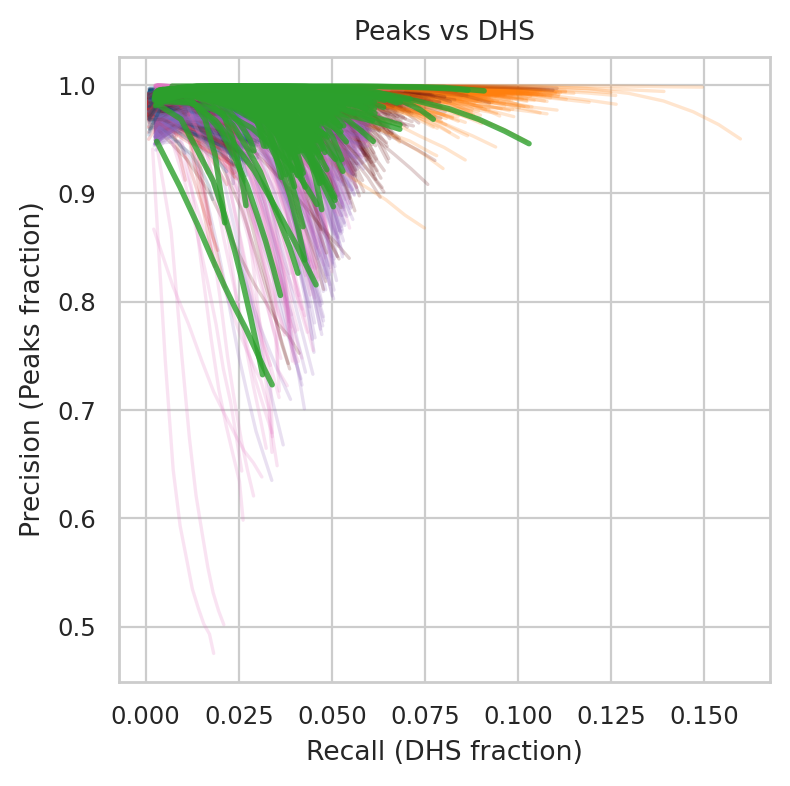

In [692]:
plt.figure(figsize=(4, 4))
for (srr, n, tool), dft in dhs_ovlp_df[dhs_ovlp_df['tool'] != 'Omnipeak'].groupby(['srr', 'name', 'tool']):
    plt.plot(dft['recall'], dft['precision'], marker='',
             color=TOOLS_PALETTE[tool], alpha=0.2)
for (srr, n, tool), dft in dhs_ovlp_df[dhs_ovlp_df['tool'] == 'Omnipeak'].groupby(['srr', 'name', 'tool']):
    plt.plot(dft['recall'], dft['precision'], marker='',
             color=TOOLS_PALETTE[tool], alpha=0.8, linewidth=2)

plt.title('Peaks vs DHS')
plt.xlabel('Recall (DHS fraction)')
plt.ylabel('Precision (Peaks fraction)')
plt.tight_layout()
plt.show()

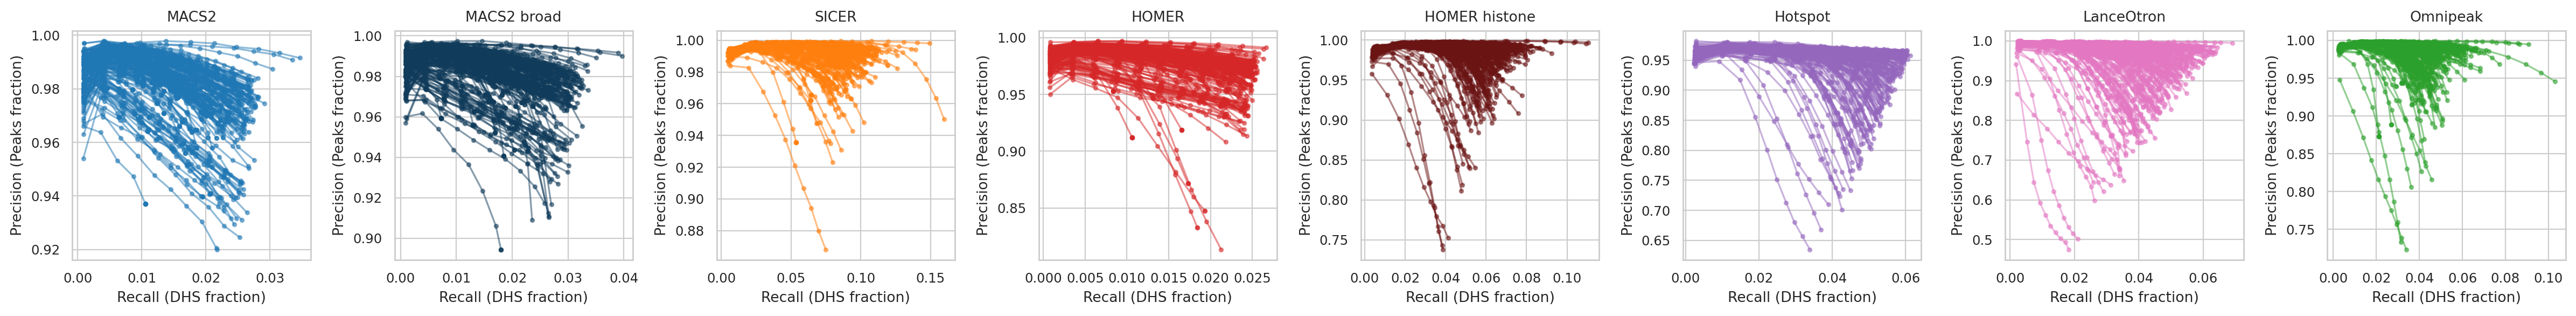

In [693]:
plt.figure(figsize=(24, 3))
axs = [plt.subplot(1, 8, i + 1) for i in range(8)]
for i, tool in enumerate(TOOLS):
    ax = axs[i]
    for (srr, n), dft in dhs_ovlp_df[dhs_ovlp_df['tool'] == tool].groupby(['srr', 'name']):
        ax.plot(dft['recall'], dft['precision'], marker='.',
                color=TOOLS_PALETTE[tool], alpha=0.5)
    ax.set_title(f'{tool}')
    ax.set_xlabel('Recall (DHS fraction)')
    ax.set_ylabel('Precision (Peaks fraction)')
plt.tight_layout()
plt.show()

SRR5799507


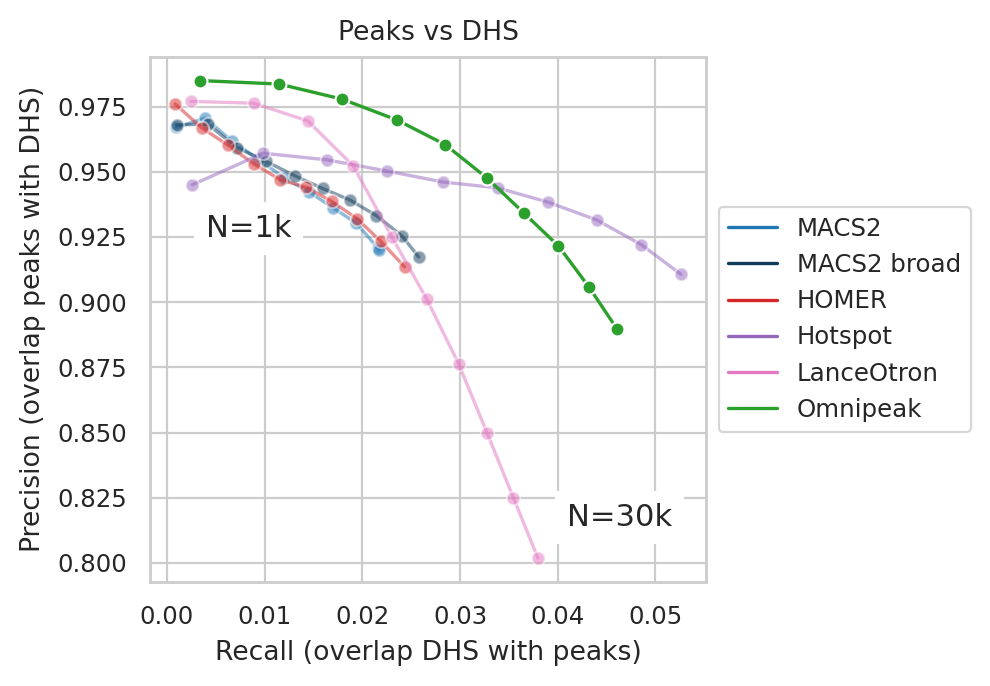

In [771]:
# srr = dhs_ovlp_df.sample(1)['srr'].values[0]
srr = 'SRR5799507'
print(srr)
plt.figure(figsize=(5, 3.5))
ax = plt.axes()
t = dhs_ovlp_df[(dhs_ovlp_df['srr'] == srr)]
sns.lineplot(
    data=t[t['tool'] != 'Omnipeak'],
    y='precision', x='recall',
    hue_order=TOOLS_LIMITED,
    hue='tool', marker='o',
    alpha=0.5,
    sort=False,
    palette=TOOLS_PALETTE,
    ax=ax
)
sns.lineplot(
    data=t[t['tool'] == 'Omnipeak'],
    y='precision', x='recall',
    hue_order=TOOLS_LIMITED,
    hue='tool', marker='o',
    alpha=1,
    markersize=5,
    sort=False,
    palette=TOOLS_PALETTE,
    legend=False,
    ax=ax
)

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.text(0.1, 0.70, "N=1k",
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=1))
ax.text(0.75, 0.15, "N=30k",
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=1))
plt.title('Peaks vs DHS')
plt.ylabel('Precision (overlap peaks with DHS)')
plt.xlabel('Recall (overlap DHS with peaks)')

plt.tight_layout()
plt.show()

One of the key limitations of AUROC becomes most apparent on highly imbalanced datasets
(low % of positives, lots of negatives), e.g. many medical datasets, rare event detection problems, etc.
Small changes in the number of false positives/false negatives can severely shift AUROC.
AUPR, which plots precision vs. recall is more robust to this problem.

In [695]:
rows = []
for (srr, n, tool), dft in dhs_ovlp_df.groupby(['srr', 'name', 'tool']):
    dft.sort_values(by=['top'], inplace=True)
    ap = 0
    rpev, pprev = None, None
    for _, row in dft.iterrows():
        if rpev is not None and pprev is not None:
            ap += (row['recall'] - rpev) * (row['precision'] + pprev) / 2
        rpev, pprev = row['recall'], row['precision']
    rows.append((srr, n, tool, ap))
dhs_ovlp_df_df = pd.DataFrame(rows, columns=['srr', 'name', 'tool', 'auc'])
del rows
dhs_ovlp_df_df.sample(2)

,srr,name,tool,auc
776,SRR5799478,Spleen_NKT_Cell,Hotspot,0.050453
1470,SRR8186436,Thymus_DP_Thymocytes,HOMER,0.025682


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Hotspot vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:8.401e-10 U_stat=2.343e+04
HOMER vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.038e-60 U_stat=2.040e+02
MACS2 broad vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:7.014e-57 U_stat=7.630e+02
MACS2 vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.595e-60 U_stat=2.970e+02


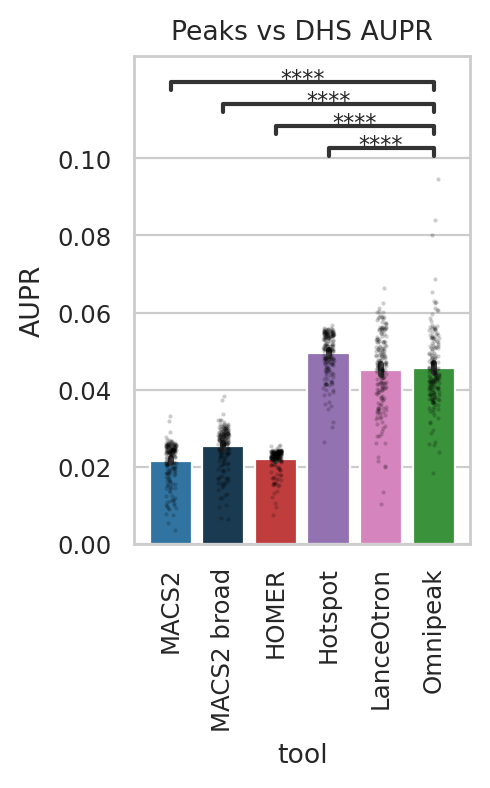

In [803]:
plt.figure(figsize=(2.5, 4))
ax = plt.axes()
ax.title.set_text('Peaks vs DHS AUPR')
t = dhs_ovlp_df_df
sns.barplot(data=t, x='tool', y='auc',
            # capsize=.1, err_kws={'linewidth': 2},
            order=TOOLS_LIMITED,
            palette=TOOLS_PALETTE,
            ax=ax)
sns.stripplot(data=t, x='tool', y='auc',
              dodge=True, size=1.5, color="black", alpha=0.2,
              order=TOOLS_LIMITED,
              ax=ax)

ax.xaxis.set_tick_params(rotation=90)
ax.set_ylabel('AUPR')

pairs = [(tool, 'Omnipeak') for tool in TOOLS_LIMITED if tool != 'Omnipeak']  # which groups to compare
annot = Annotator(ax, pairs, data=t, x='tool', y='auc', order=TOOLS_LIMITED)
annot.configure(test='Mann-Whitney', comparisons_correction="BH", correction_format="replace",
                hide_non_significant=True,
                verbose=2,
                text_offset=-3, line_offset=0)
annot.apply_test()
annot.annotate()

ax.set_yticks(np.arange(0, 0.11, step=0.02), minor=False)
# ax.set_yticks(np.arange(0.2, 0.8, step=0.1), minor=False)
# ax.set_ylim(0.4, 1)

plt.tight_layout()
plt.show()

In [697]:
# AUPR vs average length
t = pd.merge(dhs_ovlp_df_df[['srr', 'tool', 'auc']], df_lens_avg, on=['srr', 'tool'], how='inner')
t.sample()

,srr,tool,auc,length
394,SRR5799430,MACS2,0.018025,168.38575


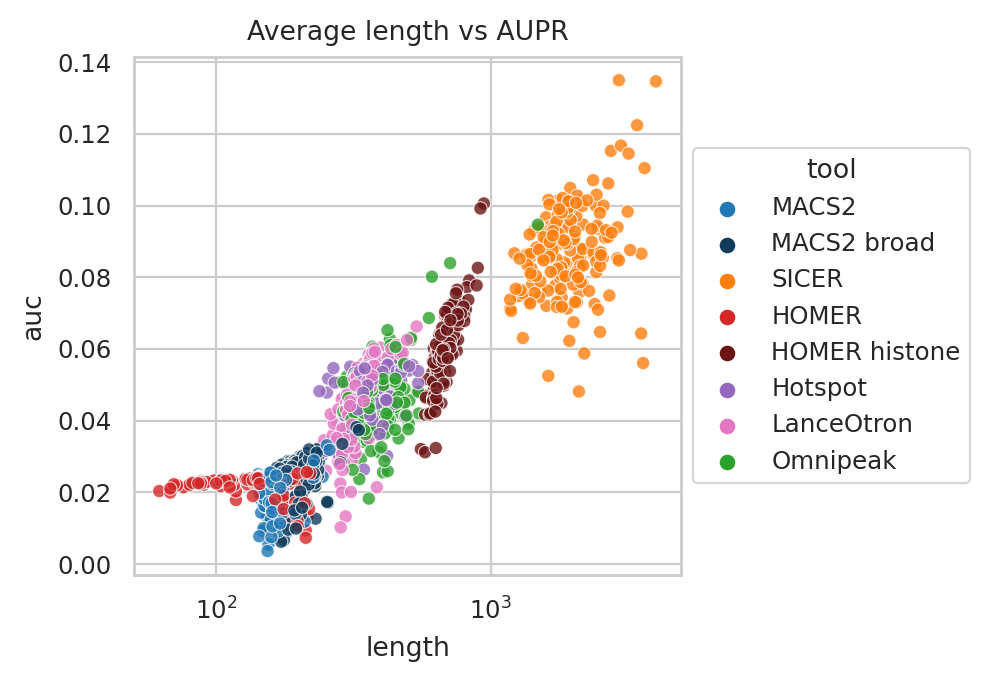

In [698]:
plt.figure(figsize=(5, 3.5))
ax = plt.axes()
sns.scatterplot(
    t, x='length', y='auc',
    hue='tool',
    hue_order=TOOLS,
    palette=TOOLS_PALETTE,
    alpha=0.8,
    ax=ax)
ax.set(xscale="log")
ax.title.set_text('Average length vs AUPR')
sns.move_legend(ax, loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

## by length

In [699]:
dhs_ovlp_df['precision_len'] = [
    d(x, y) for x, y in zip(dhs_ovlp_df['overlap_len'], dhs_ovlp_df['peaks_len'])]
dhs_ovlp_df['recall_len'] = [
    d(x, y) for x, y in zip(dhs_ovlp_df['overlap_len'], dhs_ovlp_df['dhs_len'])]

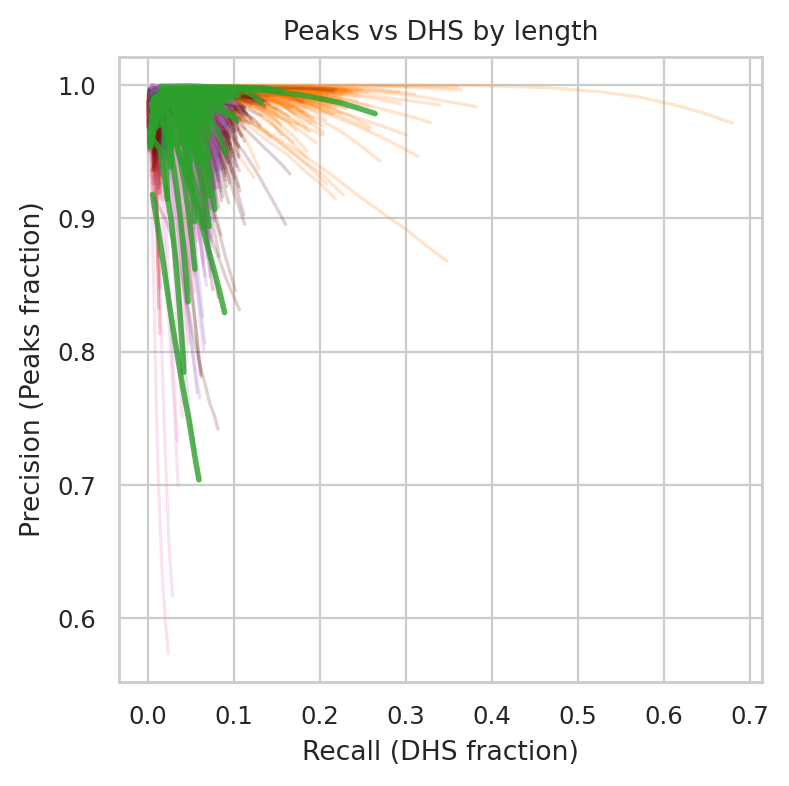

In [700]:
plt.figure(figsize=(4, 4))
for (srr, n, tool), dft in dhs_ovlp_df[dhs_ovlp_df['tool'] != 'Omnipeak'].groupby(['srr', 'name', 'tool']):
    plt.plot(dft['recall_len'], dft['precision_len'], marker='',
             color=TOOLS_PALETTE[tool], alpha=0.2)
for (srr, n, tool), dft in dhs_ovlp_df[dhs_ovlp_df['tool'] == 'Omnipeak'].groupby(['srr', 'name', 'tool']):
    plt.plot(dft['recall_len'], dft['precision_len'], marker='',
             color=TOOLS_PALETTE[tool], alpha=0.8, linewidth=2)

plt.title('Peaks vs DHS by length')
plt.xlabel('Recall (DHS fraction)')
plt.ylabel('Precision (Peaks fraction)')
plt.tight_layout()
plt.show()

SRR5799503


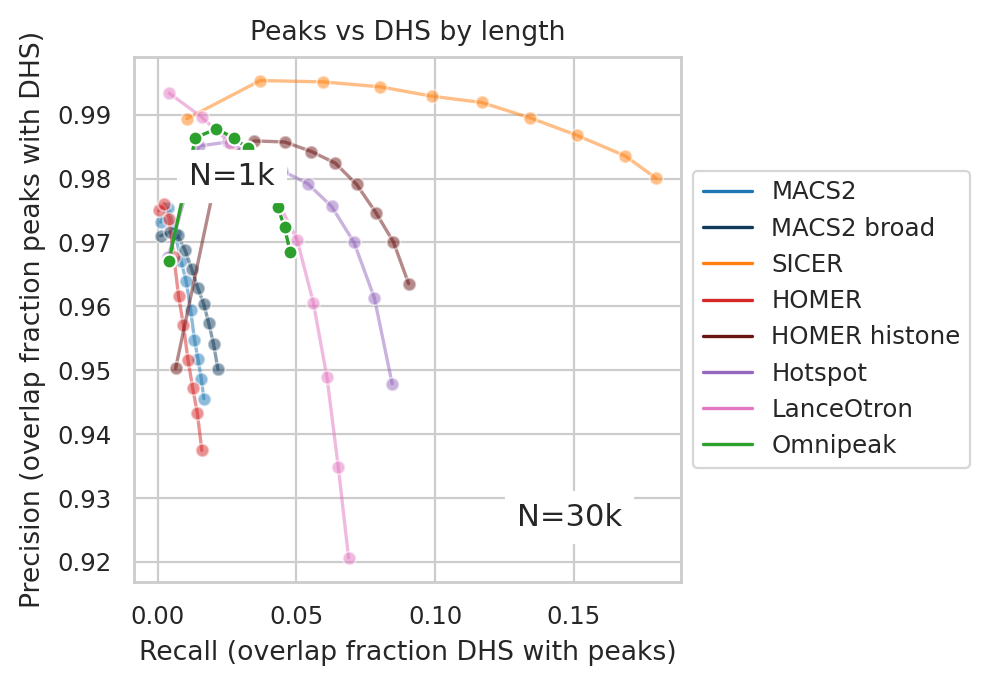

In [701]:
# srr = dhs_ovlp_df.sample(1)['srr'].values[0]
srr = 'SRR5799503'
print(srr)
plt.figure(figsize=(5, 3.5))
ax = plt.axes()
t = dhs_ovlp_df[(dhs_ovlp_df['srr'] == srr)]
sns.lineplot(
    data=t[t['tool'] != 'Omnipeak'],
    x='recall_len', y='precision_len',
    hue_order=TOOLS,
    hue='tool', marker='o',
    alpha=0.5,
    sort=False,
    palette=TOOLS_PALETTE,
    ax=ax
)
sns.lineplot(
    data=t[t['tool'] == 'Omnipeak'],
    x='recall_len', y='precision_len',
    hue_order=TOOLS,
    hue='tool', marker='o',
    alpha=1,
    markersize=5,
    sort=False,
    palette=TOOLS_PALETTE,
    legend=False,
    ax=ax
)

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.text(0.1, 0.80, "N=1k",
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=1))
ax.text(0.7, 0.15, "N=30k",
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=1))
plt.title('Peaks vs DHS by length')
plt.ylabel('Precision (overlap fraction peaks with DHS)')
plt.xlabel('Recall (overlap fraction DHS with peaks)')

plt.tight_layout()
plt.show()

# Bigwigs based coverage

In [702]:
def atac_load_bws(path):
    df = pd.DataFrame(columns=['file', 'srr', 'name'], dtype=object)
    for f in tqdm(os.listdir(path)):
        if not f.endswith('.bw'):
            continue
        file = os.path.join(path, f)
        df.loc[len(df)] = (file, file_to_srr(f), file_to_name(f))
    return df


df_bws = atac_load_bws(PATH + '/bw')
df_bws.sample(3)

  0%|          | 0/185 [00:00<?, ?it/s]

,file,srr,name
13,/home/jetbrains/data/2024_Immgen/bw/SRR5799405...,SRR5799405,Bone_marrow_Neutrophil
107,/home/jetbrains/data/2024_Immgen/bw/SRR5799453...,SRR5799453,Bone_marrow_B_Cell
143,/home/jetbrains/data/2024_Immgen/bw/SRR5799535...,SRR5799535,Spleen_CD4_Naive_T_Cell


In [703]:
# ! conda install pyBigWig -c bioconda -y

In [704]:
import pyBigWig

CHROM_SIZES = {
    c: s for _, (c, s) in pd.read_csv(os.path.join(PATH, 'mm10.chrom.sizes'),
                                      sep='\t', names=['chr', 'size']).iterrows() if '_' not in c
}

total_coverages = {}
ts = []
for _, (file, srr, name) in tqdm(list(df_bws[['file', 'srr', 'name']].iterrows())):
    try:
        with pyBigWig.open(file) as bw:
            total_coverage = sum(
                bw.stats(chr, exact=True, type='sum')[0] for chr in CHROM_SIZES.keys() if '_' not in chr)
            print('Total coverage', total_coverage)
            # Multiplier to align BAM coverage with BigWig estimation
            total_coverage *= 1.1e-2
            total_coverages[(srr, name)] = total_coverage
    except Exception:
        pass

total_coverages

  0%|          | 0/185 [00:00<?, ?it/s]

Total coverage 68706944.28250217
Total coverage 63545909.384791374
Total coverage 76152597.54262495
Total coverage 75180143.34051704
Total coverage 67265985.9938128
Total coverage 70976950.71421719
Total coverage 67699902.12035751
Total coverage 50040405.83816624
Total coverage 79785138.91390991
Total coverage 56215488.798733234
Total coverage 75621080.8723154
Total coverage 69820939.83396196
Total coverage 64223934.234651804
Total coverage 76262475.75324893
Total coverage 69310119.13946962
Total coverage 70073806.75087357
Total coverage 56029175.884141445
Total coverage 62309602.363991976
Total coverage 31460709.967515707
Total coverage 71759779.20138836
Total coverage 61197839.32630229
Total coverage 74032008.30245543
Total coverage 65423567.254221916
Total coverage 60717014.28111029
Total coverage 71577321.26472378
Total coverage 63254705.361252785
Total coverage 55841983.48340988
Total coverage 50452470.5484221
Total coverage 67069842.574133635
Total coverage 61904199.17429662
Tota

{('SRR5799401', 'Spleen_Activated_T_Cell'): 755776.3871075239,
 ('SRR5799541', 'Blood_Monocyte'): 699005.003232705,
 ('SRR5799407', 'Spleen_Neutrophil'): 837678.5729688744,
 ('SRR5799536', 'Peritoneal_cavity_Macrophage'): 826981.5767456874,
 ('SRR5799449', 'Bone_marrow_B_Cell'): 739925.8459319407,
 ('SRR5799465', 'Spleen_B_Cell'): 780746.457856389,
 ('SRR5799448', 'Bone_marrow_B_Cell'): 744698.9233239326,
 ('SRR5799446', 'Spleen_gdT_Cell'): 550444.4642198286,
 ('SRR5799500', 'Spleen_Macrophage'): 877636.528053009,
 ('SRR5799430', 'Lymph_nodes_gdT_Cell'): 618370.3767860655,
 ('SRR5799515', 'Spleen_B_Cell'): 831831.8895954695,
 ('SRR5799526', 'Small_intestine_Dendritic_Cell'): 768030.3381735815,
 ('SRR5799478', 'Spleen_NKT_Cell'): 706463.2765811698,
 ('SRR5799405', 'Bone_marrow_Neutrophil'): 838887.2332857382,
 ('SRR5799492', 'Blood_Monocyte'): 762411.3105341658,
 ('SRR5799509', 'Skin_draining_lymph_node_Stromal_Cell'): 770811.8742596091,
 ('SRR5799520', 'Lung_Macrophage'): 616320.934725

In [705]:
total_coverages_df = pd.DataFrame([(srr, name, reads) for (srr, name), reads in total_coverages.items()],
                                  columns=['srr', 'name', 'reads'])
total_coverages_df.sample(5)

,srr,name,reads
137,SRR5799459,Spleen_B_Cell,763344.983324
175,SRR5799504,Spleen_Dendritic_Cell,695831.229730
103,SRR5799540,brain_Microglia,803323.093282
133,SRR5799388,Thymus_Double_Negative_Thymocytes,749713.165715
179,SRR5799417,Bone_marrow_NK_Cell,632750.267435


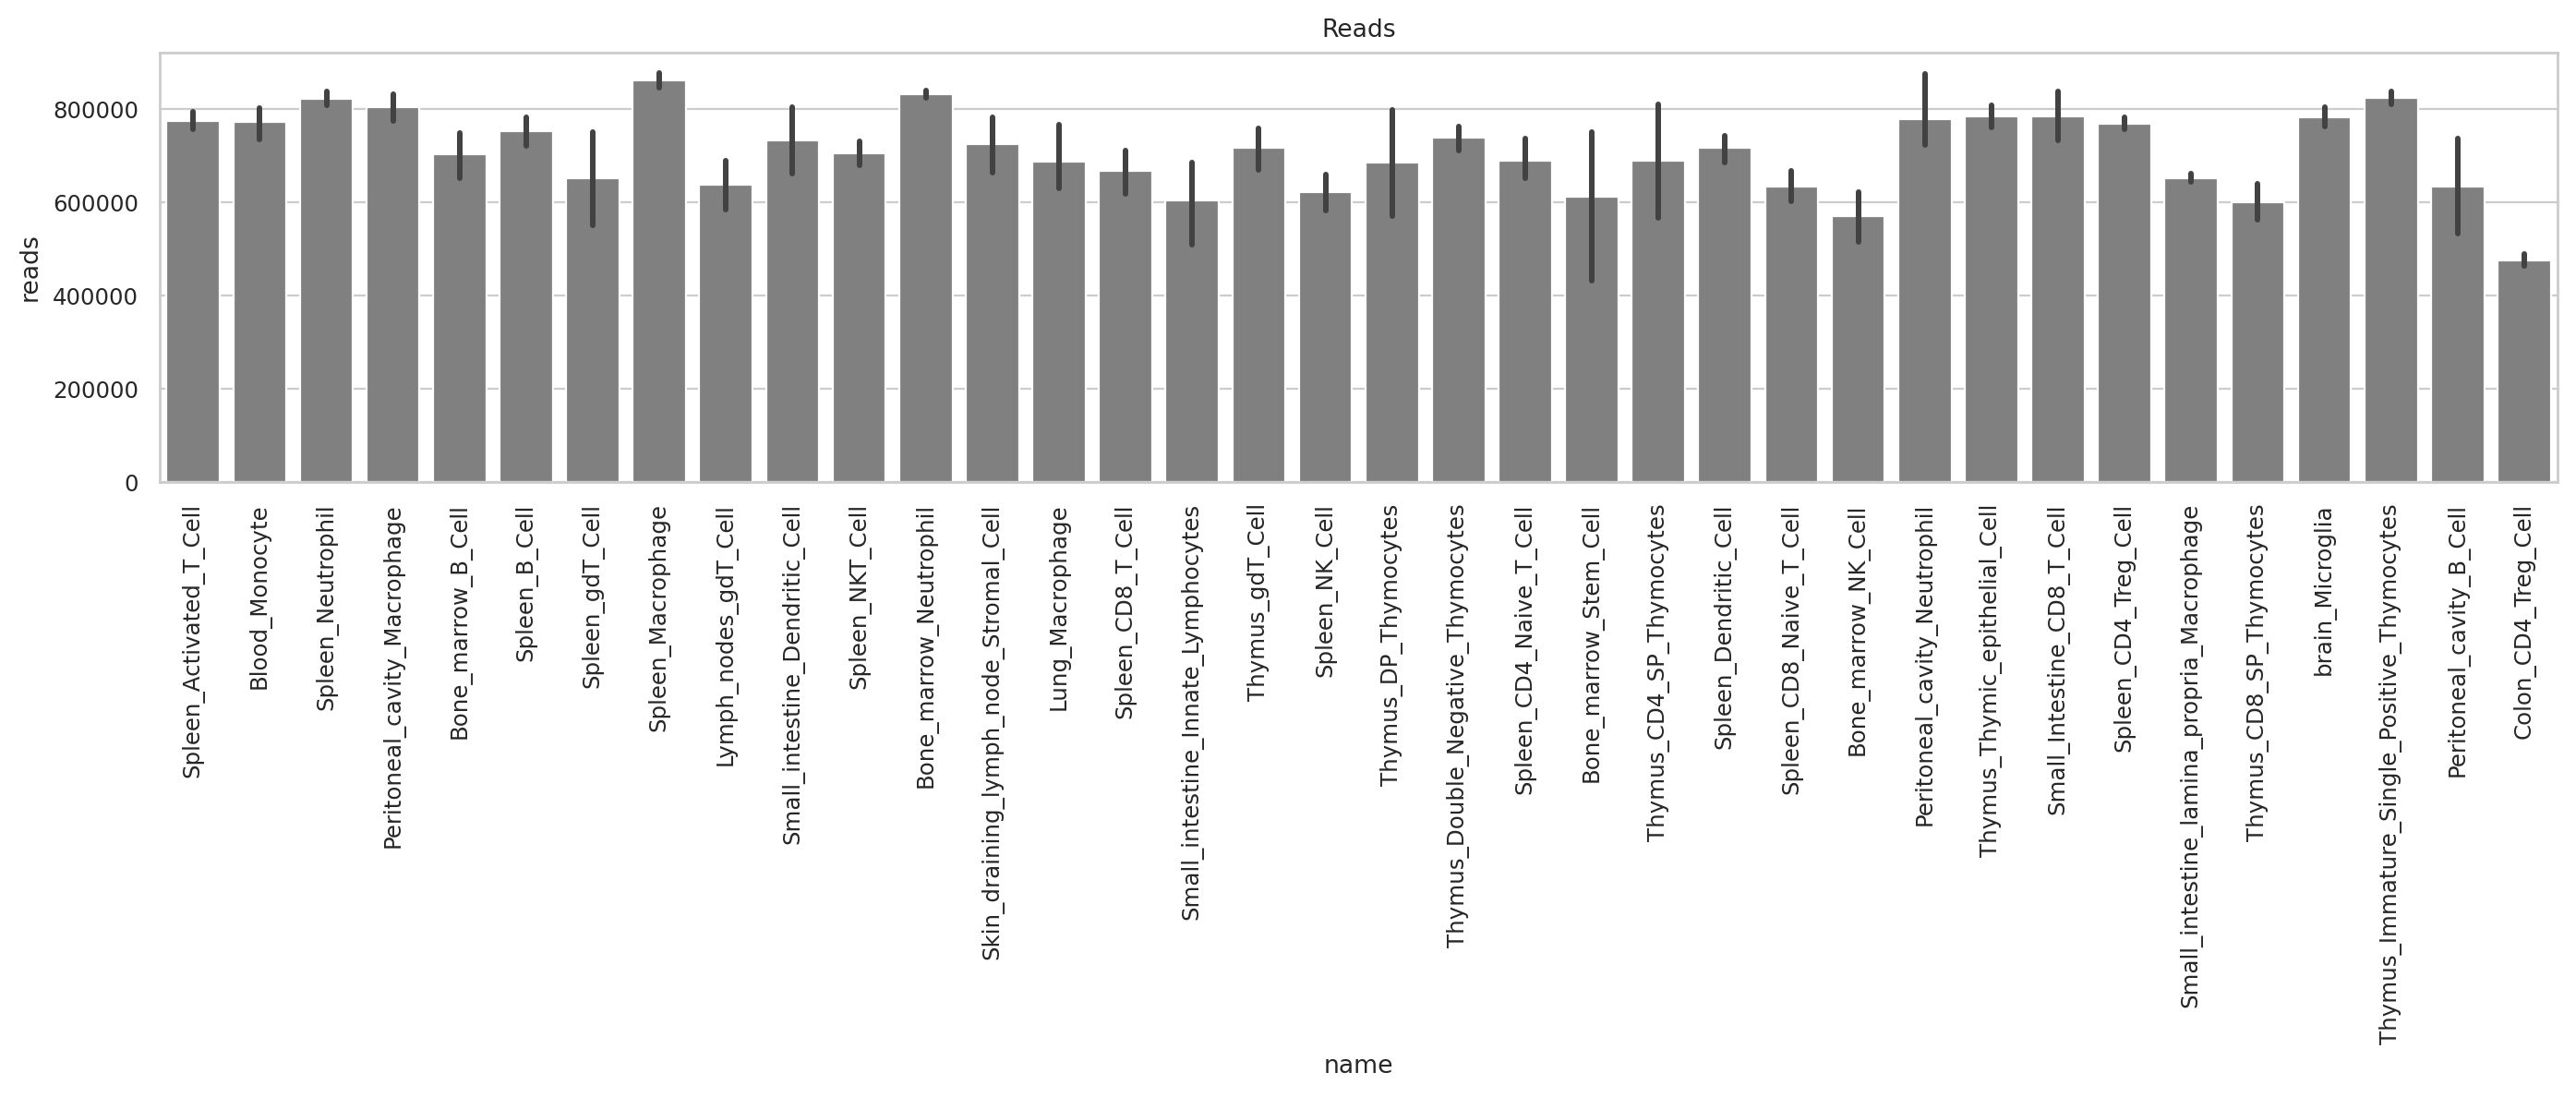

In [706]:
plt.figure(figsize=(14, 6))
g_result = sns.barplot(data=total_coverages_df, x='name', y='reads',
                       color='grey')
# g_result.axes.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=90)
plt.title('Reads')
plt.tight_layout()
plt.tight_layout()
# plt.savefig(f'{PATH}/pics/peaks.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Peaks RPKM

In [707]:
def compute_peaks_rpkm(dfa, df_bws, total_coverages):
    rows = []
    for srr in tqdm(dfa['srr'].unique()):
        print(srr)
        # Processing single tools information
        for tool in dfa['tool'].unique():
            t = dfa[(dfa['tool'] == tool) & (dfa['srr'] == srr)]
            if len(t) != 1:
                continue
            print(tool)
            file = t['file'].values[0]
            cell_name = t['name'].values[0]
            try:
                t2 = pd.read_csv(file, sep='\t', header=None)
                if len(t2.columns) == 10:  # Peakseq
                    sort_col = t2.columns[9]
                elif len(t2.columns) >= 9:
                    sort_col = t2.columns[8]
                elif len(t2.columns) >= 5:
                    sort_col = t2.columns[4]
                elif len(t2.columns) >= 4:
                    sort_col = t2.columns[3]
                else:
                    print(f'ERROR: {tool} - failed to sort file {file}')
                    continue
                t2.sort_values(by=sort_col, ascending=False, inplace=True)
            except Exception:
                print(f'ERROR: {tool} - empty or failed to read file {file}')
                continue
            totalm = total_coverages[(srr, cell_name)] * 1e-6
            # Processing single tools information
            bw_path = df_bws[(df_bws['srr'] == srr) & (df_bws['name'] == cell_name)]['file'].values[0]
            with pyBigWig.open(bw_path) as bw:
                if len(t2) == 0:
                    print(f'ERROR: {tool} - no peaks found {file}')
                    continue
                added = False
                # Some of the tools produce 100k+ peaks, pick top ones
                for _, (chr, start, end) in t2.head(1000)[[0, 1, 2]].iterrows():
                    if start >= end:
                        continue
                    try:
                        cov = bw.stats(chr, start, end, exact=True, type='sum')[0]
                    except Exception:
                        continue
                    rpk = cov / (end - start) * 1e3
                    rpm = cov / totalm
                    rpkm = rpk / totalm
                    rows.append((srr, cell_name, tool, len(t2), chr, start, end, end - start, rpk, rpm, rpkm))
                    added = True
                if not added:
                    print(f'ERROR: {tool} - no records added for {file}')

    peaks_coverage_df = pd.DataFrame(
        rows,
        columns=['srr', 'cell', 'tool', 'peaks', 'chromosome', 'start', 'end', 'length', 'rpk', 'rpm', 'rpkm'],
        dtype=object
    )
    return peaks_coverage_df

In [708]:
peaks_coverage_df_path = f'{PATH}/peaks_rpkm.tsv'
peaks_coverage_df = load_or_compute(peaks_coverage_df_path,
                                    lambda: compute_peaks_rpkm(dfa, df_bws, total_coverages))
peaks_coverage_df.sample(3)

,srr,cell,tool,peaks,chromosome,start,end,length,rpk,rpm,rpkm
610345,SRR5799483,Small_intestine_Innate_Lymphocytes,HOMER,26765,chr5,68012775,68012951,176,322.886713,78.737711,447.373356
1139058,SRR5799482,Spleen_NKT_Cell,SICER,22880,chr13,3537400,3540199,2799,667.651716,2367.440590,845.816574
34645,SRR5799492,Blood_Monocyte,Omnipeak,34221,chr2,13271100,13271645,545,1790.333493,1279.797060,2348.251486


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

LanceOtron vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:0.000e+00 U_stat=1.388e+10
Hotspot vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.777e-239 U_stat=1.595e+10
HOMER histone vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:0.000e+00 U_stat=1.247e+10
HOMER vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:0.000e+00 U_stat=4.832e+09
SICER vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:0.000e+00 U_stat=8.851e+09
MACS2 broad vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:0.000e+00 U_stat=2.763e+10
MACS2 vs. Omnipeak: Mann-Whitn

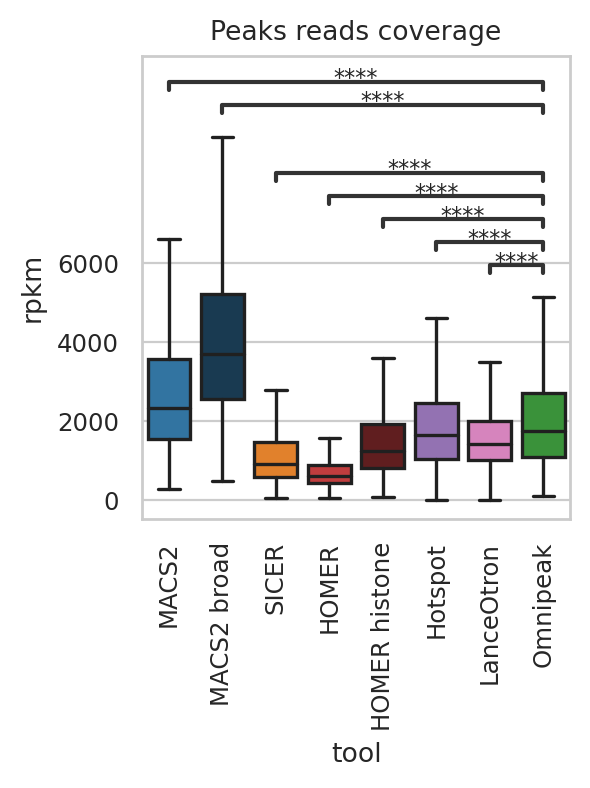

In [709]:
plt.figure(figsize=(3, 4))
ax = plt.axes()
ax.title.set_text('Peaks reads coverage')
sns.boxplot(data=peaks_coverage_df, x='tool', y='rpkm',
            showfliers=False,
            order=TOOLS,
            palette=TOOLS_PALETTE,
            ax=ax)

ax.xaxis.set_tick_params(rotation=90)
ax.set_ylabel('rpkm')

pairs = [(tool, 'Omnipeak') for tool in TOOLS if tool != 'Omnipeak']  # which groups to compare
annot = Annotator(ax, pairs, data=peaks_coverage_df, x='tool', y='rpkm', order=TOOLS, )
annot.configure(test='Mann-Whitney', comparisons_correction="BH", correction_format="replace",
                hide_non_significant=True,
                verbose=2,
                text_offset=-3, line_offset=0)
annot.apply_test()
annot.annotate()

ax.set_yticks(np.arange(0, 7000, step=2000), minor=False)

plt.tight_layout()
plt.show()

In [710]:
peaks_coverage_avg_df = peaks_coverage_df[['srr', 'tool', 'rpkm']].groupby(['srr', 'tool']).mean().reset_index()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

LanceOtron vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.032e-15 U_stat=8.741e+03
Hotspot vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:8.286e-21 U_stat=2.674e+04
HOMER histone vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.631e-08 U_stat=1.130e+04
HOMER vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:9.896e-52 U_stat=1.546e+03
SICER vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.593e-20 U_stat=7.676e+03
MACS2 broad vs. Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.285e-22 U_stat=2.718e+04
MACS2 vs. Omnipeak: Mann-Whitne

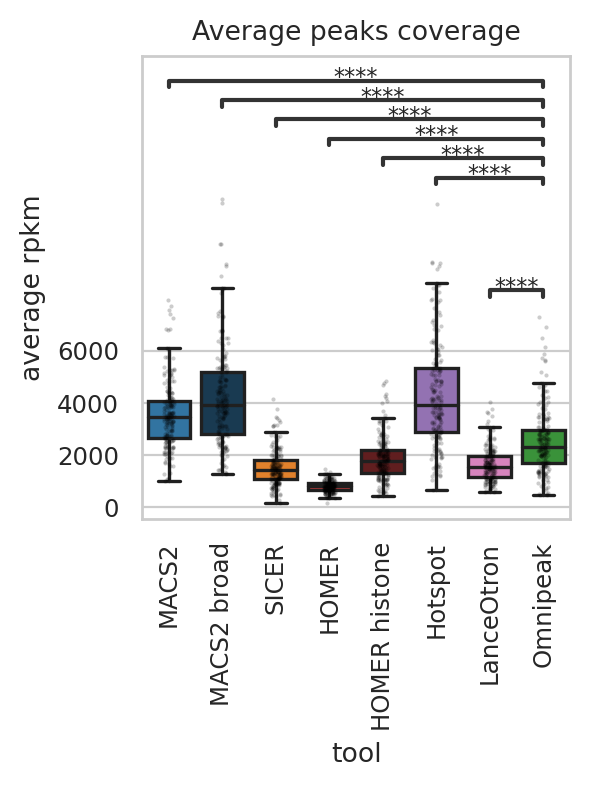

In [808]:
# Average RPKM per tool
plt.figure(figsize=(3, 4))
ax = plt.axes()
ax.title.set_text('Average peaks coverage')
sns.boxplot(data=peaks_coverage_avg_df, x='tool', y='rpkm',
            showfliers=False,
            order=TOOLS,
            palette=TOOLS_PALETTE,
            ax=ax)
sns.stripplot(data=peaks_coverage_avg_df, x='tool', y='rpkm',
              alpha=0.2, dodge=True, size=1.5, color="black",
              order=TOOLS,
              ax=ax)

ax.xaxis.set_tick_params(rotation=90)
ax.set_ylabel('average rpkm')

pairs = [(tool, 'Omnipeak') for tool in TOOLS if tool != 'Omnipeak']  # which groups to compare
annot = Annotator(ax, pairs, data=peaks_coverage_avg_df, x='tool', y='rpkm', order=TOOLS, )
annot.configure(test='Mann-Whitney', comparisons_correction="BH", correction_format="replace",
                hide_non_significant=True,
                verbose=2,
                text_offset=-3, line_offset=0)
annot.apply_test()
annot.annotate()

ax.set_yticks(np.arange(0, 7000, step=2000), minor=False)

plt.tight_layout()
plt.show()

# Difference

In [712]:
def compute_diff(dfa):
    rows = []
    for srr in tqdm(dfa['srr'].unique()):
        print(srr)
        t = dfa[(dfa['tool'] == 'Omnipeak') & (dfa['srr'] == srr)]
        if len(t) == 0:
            continue
        omnipeak_path = t['file'].values[0]
        omnipeak_file, omnipeak_peaks, _ = load(sorted_file(omnipeak_path))
        cell_name = t['name'].values[0]
        # Processing single tools information
        for tool in TOOLS:
            if tool == 'Omnipeak':
                continue
            t = dfa[(dfa['tool'] == tool) & (dfa['srr'] == srr)]
            if len(t) == 0:
                continue
            peaks_path = t['file'].values[0]
            peaks_file, peaks, _ = load(sorted_file(peaks_path))
            if omnipeak_peaks == 0:
                rows.append((cell_name, srr, f'Omnipeak - {tool}', 0))
                rows.append((cell_name, srr, f'{tool} - Omnipeak', peaks))
            elif peaks == 0:
                rows.append((cell_name, srr, f'Omnipeak - {tool}', omnipeak_peaks))
                rows.append((cell_name, srr, f'{tool} - Omnipeak', 0))
            else:
                rows.append((cell_name, srr, f'Omnipeak - {tool}',
                             len(omnipeak_file.overlap(peaks_file, invert=True))))
                rows.append((cell_name, srr, f'{tool} - Omnipeak',
                             len(peaks_file.overlap(omnipeak_file, invert=True))))
    diff_bench_df = pd.DataFrame(rows, columns=['cell', 'srr', 'name', 'peaks'])
    return diff_bench_df

In [713]:
diff_bench_df_path = f'{PATH}/diff_bench_df.tsv'
diff_bench_df = load_or_compute(diff_bench_df_path, lambda: compute_diff(dfa))
diff_bench_df.sample(3)

,cell,srr,name,peaks
186,Bone_marrow_B_Cell,SRR5799453,Omnipeak - SICER,3705
1960,Spleen_NKT_Cell,SRR5799479,Omnipeak - MACS2 broad,9290
1175,Spleen_B_Cell,SRR5799560,MACS2 - Omnipeak,46


In [714]:
DIFF_PALETTE = {}
for tool in TOOLS:
    if tool != 'Omnipeak':
        DIFF_PALETTE[f'Omnipeak - {tool}'] = TOOLS_PALETTE[tool]
        DIFF_PALETTE[f'{tool} - Omnipeak'] = TOOLS_PALETTE[tool]

Diff


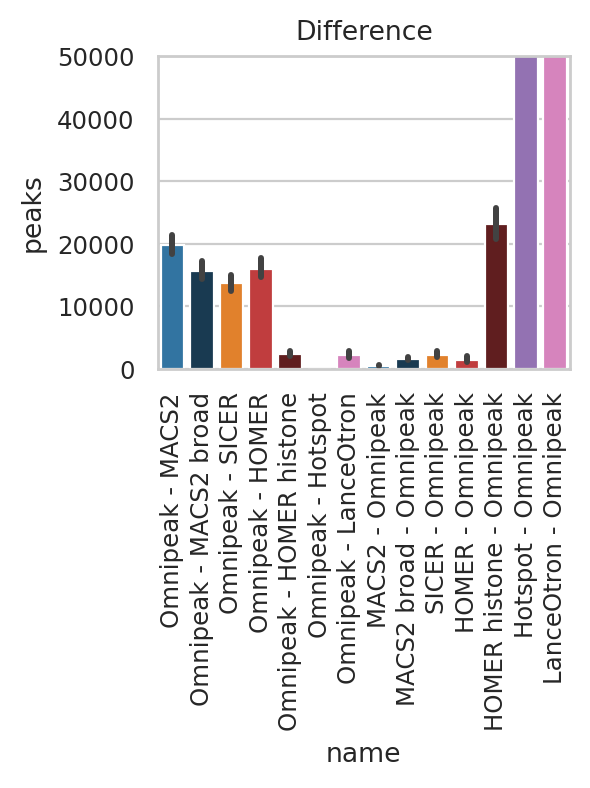

In [715]:
print('Diff')

plt.figure(figsize=(3, 4))
ax = plt.axes()
sns.barplot(data=diff_bench_df,
            x='name', y='peaks',
            order=[f'Omnipeak - {tool}' for tool in TOOLS if tool != 'Omnipeak'] +
                  [f'{tool} - Omnipeak' for tool in TOOLS if tool != 'Omnipeak'],
            palette=DIFF_PALETTE,
            ax=ax)
ax.xaxis.set_tick_params(rotation=90)
ax.set_ylim(0, 50_000)
ax.set_title('Difference')
# g_result.axes.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig(f'{PATH}/pics/difference.pdf', bbox_inches='tight', dpi=300)
plt.show()

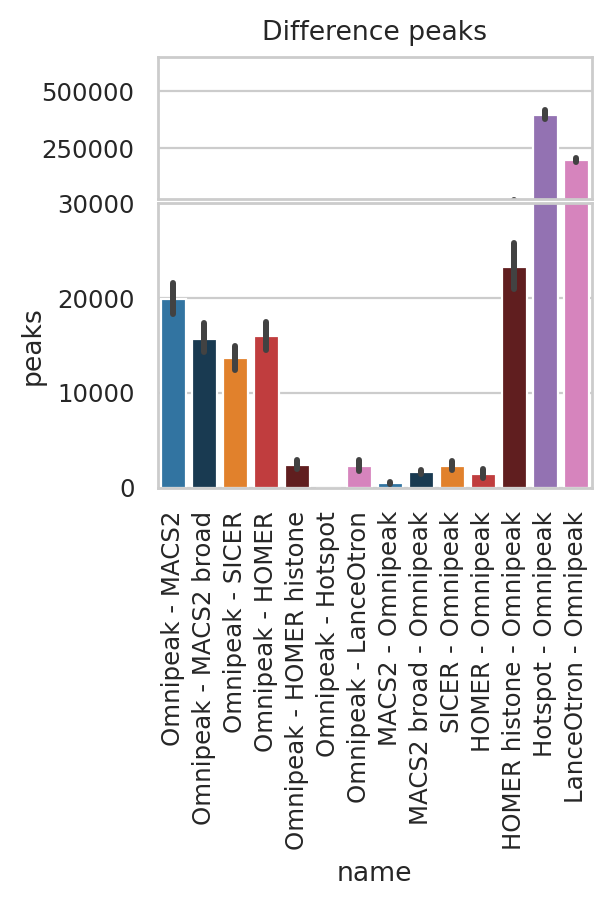

In [716]:
# Set up the matplotlib figure with broken y-axis
f, (axt, ax) = plt.subplots(2, 1, sharex=True, figsize=(2.8, 2.8),
                            gridspec_kw={'height_ratios': [1, 2]})
for j, axes in enumerate([ax, axt]):
    sns.barplot(data=diff_bench_df,
                x='name', y='peaks',
                order=[f'Omnipeak - {tool}' for tool in TOOLS if tool != 'Omnipeak'] +
                      [f'{tool} - Omnipeak' for tool in TOOLS if tool != 'Omnipeak'],
                palette=DIFF_PALETTE,
                ax=axes)
ax.set_ylim(0, 30_000)
axt.set_ylim(30_000, 650_000)
axt.set_xlabel(None)
axt.set_ylabel(None)
ax.xaxis.set_tick_params(rotation=90)
axt.title.set_text('Difference peaks')
ax.set_ylabel('peaks')
# plt.tight_layout()
plt.subplots_adjust(hspace=0.02)  # Adjust hspace closer to zero to remove spacing
plt.show()

Diff


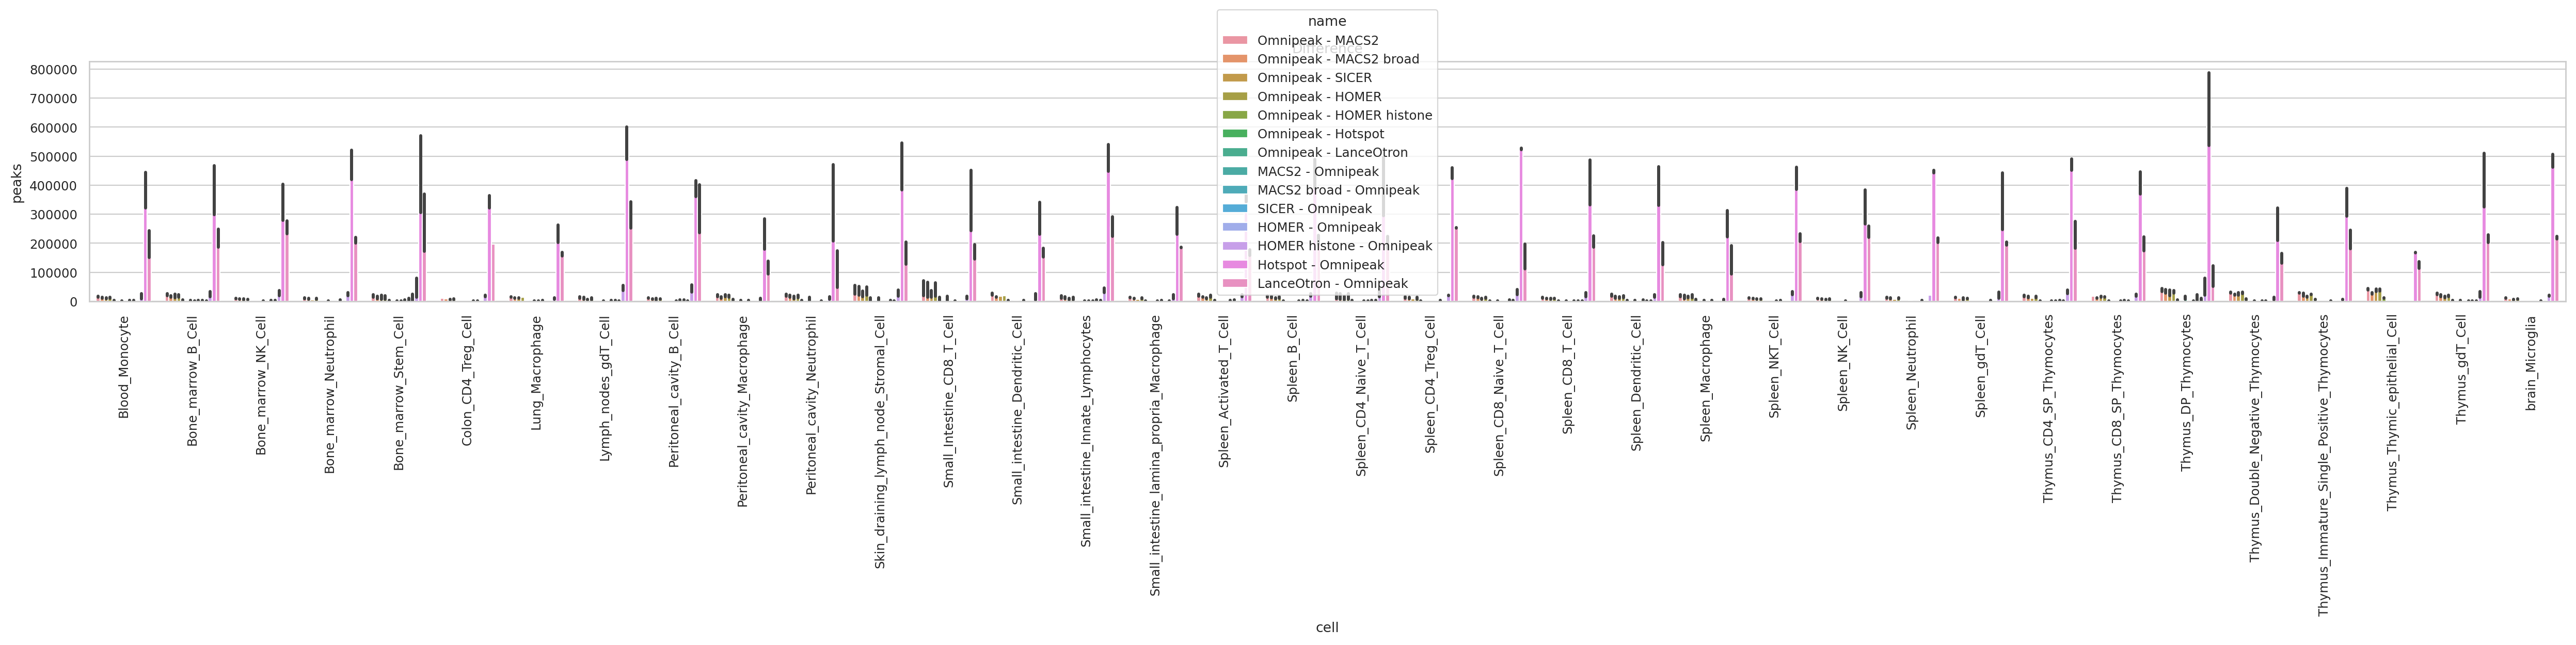

In [717]:
print('Diff')

plt.figure(figsize=(25, 6))
sns.barplot(data=diff_bench_df,
            x='cell', y='peaks', hue='name',
            hue_order=[f'Omnipeak - {tool}' for tool in TOOLS if tool != 'Omnipeak'] +
                      [f'{tool} - Omnipeak' for tool in TOOLS if tool != 'Omnipeak'],
            # errorbar='sd', capsize=.05, err_kws={'linewidth': 2},
            )
plt.xticks(rotation=90)
plt.title('Difference')
# sns.move_legend(ax, loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig(f'{PATH}/pics/difference.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Difference coverage

In [718]:
def compute_diff_coverage(dfa):
    tf = tempfile.mktemp()

    rows = []
    for srr in tqdm(dfa['srr'].unique()):
        print(srr)
        t = dfa[(dfa['tool'] == 'Omnipeak') & (dfa['srr'] == srr)]
        if len(t) != 1:
            continue
        omnipeak_file = sorted_file(t['file'].values[0])
        cell_name = t['name'].values[0]
        totalm = total_coverages[(srr, cell_name)] * 1e-6
        # Processing single tools information
        bw_path = df_bws[(df_bws['srr'] == srr) & (df_bws['name'] == cell_name)]['file'].values[0]
        with pyBigWig.open(bw_path) as bw:
            for tool in dfa['tool'].unique():
                if tool == 'Omnipeak':
                    continue
                t = dfa[(dfa['tool'] == tool) & (dfa['srr'] == srr)]
                if len(t) != 1:
                    continue
                peaks_file = sorted_file(t['file'].values[0])
                for name, args in [
                    (f'Omnipeak - {tool}', f' -a {omnipeak_file} -b {peaks_file} '),
                    (f'{tool} - Omnipeak', f' -b {omnipeak_file} -a {peaks_file} ')]:
                    ! echo '' > {tf}
                    ! bedtools intersect {args} -wa -v > {tf}
                    if lines(tf) == 0:
                        continue
                    t2 = pr.read_bed(sorted_file10(tf), as_df=True)
                    sort_col, ascending = how_to_sort(t2, tool)
                    t2.sort_values(by=sort_col, ascending=ascending, inplace=True)
                    for _, row in t2.head(50).iterrows():
                        chr, start, end = row[0], row[1], row[2]
                        if start >= end:
                            continue
                        if 'M' in chr or '_' in chr:
                            continue
                        cov = bw.stats(chr, start, end, exact=True, type='sum')[0]
                        rpk = cov / (end - start) * 1e3
                        rpm = cov / totalm
                        rpkm = rpk / totalm
                        rows.append((srr, cell_name, name, len(t2), chr, start, end, end - start, rpk, rpm, rpkm))
                ! rm {peaks_file} {tf}
    diff_bench_coverage_df = pd.DataFrame(
        rows,
        columns=['srr', 'cell', 'name', 'peaks', 'chromosome', 'start', 'end', 'length', 'rpk', 'rpm', 'rpkm'],
        dtype=object
    )
    return diff_bench_coverage_df

In [719]:
diff_bench_coverage_df_path = f'{PATH}/diff_bench_coverage_df.tsv'
diff_bench_coverage_df = load_or_compute(diff_bench_coverage_df_path, lambda : compute_diff_coverage(dfa))
diff_bench_coverage_df.sample(3)

,srr,cell,name,peaks,chromosome,start,end,length,rpk,rpm,rpkm
32520,SRR5799510,Skin_draining_lymph_node_Stromal_Cell,LanceOtron - Omnipeak,195053,chr7,16780167,16780559,392,133.476010,63.025655,160.779732
62101,SRR5799559,Spleen_CD4_Treg_Cell,Omnipeak - LanceOtron,946,chr16,96589800,96589980,180,128.103198,29.492157,163.845317
80401,SRR5799411,Spleen_NK_Cell,Omnipeak - HOMER,5368,chr2,18676455,18677510,1055,315.808423,537.089165,509.089256


Diff


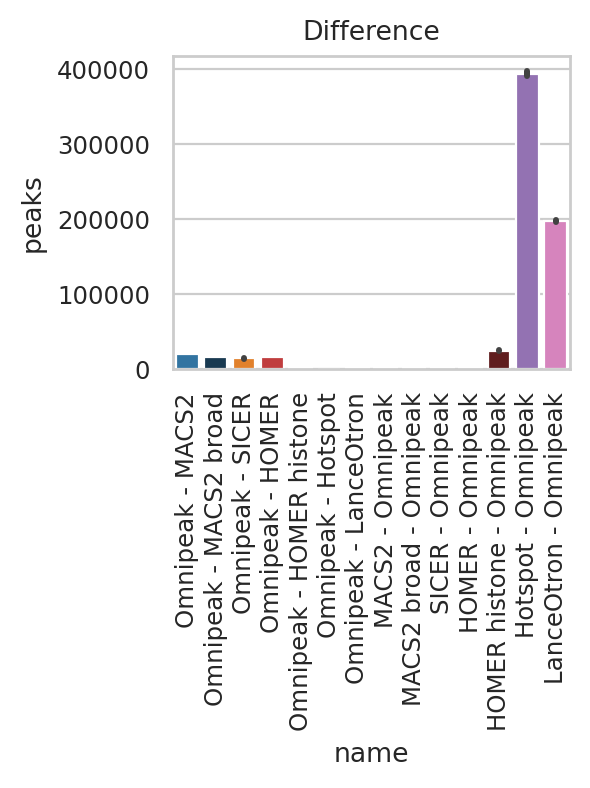

In [720]:
print('Diff')

plt.figure(figsize=(3, 4))
sns.barplot(data=diff_bench_coverage_df,
            x='name', y='peaks',
            order=[f'Omnipeak - {tool}' for tool in TOOLS if tool != 'Omnipeak'] +
                  [f'{tool} - Omnipeak' for tool in TOOLS if tool != 'Omnipeak'],
            palette=DIFF_PALETTE,
            )
plt.xticks(rotation=90)
plt.title('Difference')
# g_result.axes.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
# plt.savefig(f'{PATH}/pics/difference.pdf', bbox_inches='tight', dpi=300)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


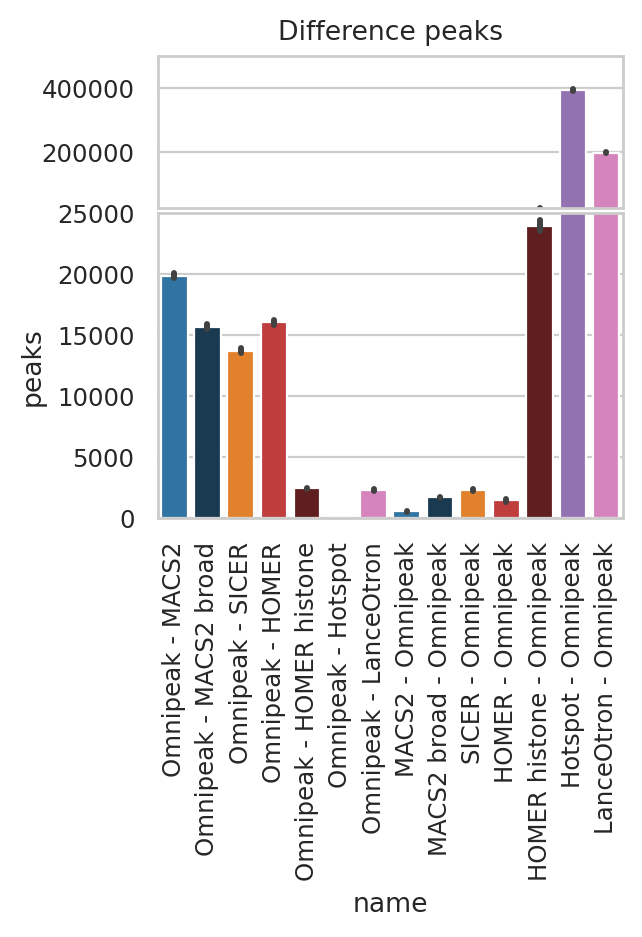

In [721]:
# Set up the matplotlib figure with broken y-axis
f, (axt, ax) = plt.subplots(2, 1, sharex=True, figsize=(3, 3),
                            gridspec_kw={'height_ratios': [1, 2]})
for j, axes in enumerate([ax, axt]):
    sns.barplot(data=diff_bench_coverage_df,
                x='name', y='peaks',
                order=[f'Omnipeak - {tool}' for tool in TOOLS if tool != 'Omnipeak'] +
                      [f'{tool} - Omnipeak' for tool in TOOLS if tool != 'Omnipeak'],
                palette=DIFF_PALETTE,
                ax=axes)
ax.set_ylim(0, 25_000)
axt.set_ylim(25_000, 500_000)
axt.set_xlabel(None)
axt.set_ylabel(None)
ax.xaxis.set_tick_params(rotation=90)
axt.title.set_text('Difference peaks')
ax.set_ylabel('peaks')
axt.legend().set_visible(False)
# plt.tight_layout()
plt.subplots_adjust(hspace=0.02)  # Adjust hspace closer to zero to remove spacing
plt.show()

Diff


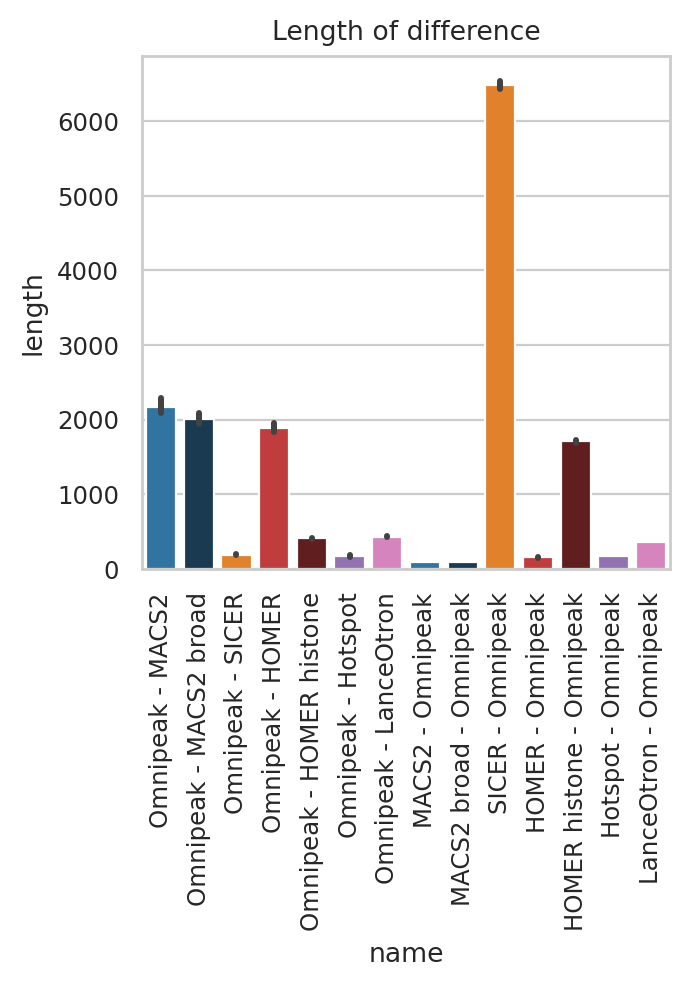

In [722]:
print('Diff')

plt.figure(figsize=(3.5, 5))
ax = plt.axes()
sns.barplot(data=diff_bench_coverage_df,
            x='name', y='length',
            order=[f'Omnipeak - {tool}' for tool in TOOLS if tool != 'Omnipeak'] +
                  [f'{tool} - Omnipeak' for tool in TOOLS if tool != 'Omnipeak'],
            palette=DIFF_PALETTE,
            ax=ax)
plt.xticks(rotation=90)
plt.title('Length of difference')
plt.tight_layout()
# plt.savefig(f'{PATH}/pics/difference.pdf', bbox_inches='tight', dpi=300)
plt.show()

Diff


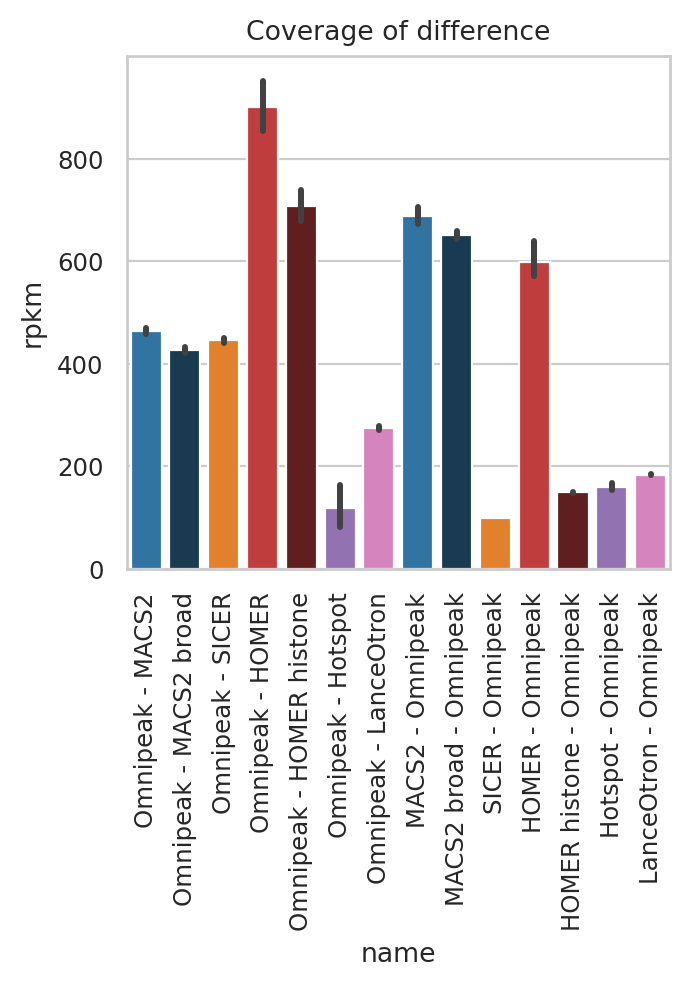

In [723]:
print('Diff')

plt.figure(figsize=(3.5, 5))
ax = plt.axes()
sns.barplot(data=diff_bench_coverage_df,
            x='name', y='rpkm',
            order=[f'Omnipeak - {tool}' for tool in TOOLS if tool != 'Omnipeak'] +
                  [f'{tool} - Omnipeak' for tool in TOOLS if tool != 'Omnipeak'],
            palette=DIFF_PALETTE,
            ax=ax)
plt.xticks(rotation=90)
plt.title('Coverage of difference')
# g_result.axes.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
# plt.savefig(f'{PATH}/pics/difference.pdf', bbox_inches='tight', dpi=300)
plt.show()

# END